# The Wake-Sleep Algorithm for Unsupervised Neural Networks — Academic Summary

**Authors:** Geoffrey E. Hinton, Peter Dayan, Brendan J. Frey, Radford M. Neal (1995)

# https://www.cs.toronto.edu/~hinton/absps/ws.pdf

## Abstract
This paper introduces the wake-sleep algorithm, an unsupervised learning procedure for multilayer networks of stochastic binary units organized into a "Helmholtz machine." The network has separate bottom-up recognition connections and top-down generative connections, trained via two alternating phases using only locally available information (no error backpropagation). The algorithm minimizes an information-theoretic "description length" objective, learning economical, structured representations without labeled data or a global teaching signal.

## Problems
- Supervised multilayer neural network training requires a teacher signal specifying desired outputs, which is unavailable in unsupervised settings.
- Supervised methods also require a mechanism for communicating error information to every connection (e.g., backpropagation), which is computationally and biologically cumbersome.
- Without an external teaching signal, some alternative objective is needed to force hidden units to discover meaningful underlying structure in unlabeled data.
- Computing the exact posterior distribution over hidden representations, $P(\alpha\mid d)$, given a generative model is exponentially expensive.
- Restricting the recognition distribution $Q(\alpha\mid d)$ to a factorial (independent per-unit) form is a strong approximation that cannot generally match the true, possibly non-factorial posterior (e.g., cannot capture "explaining away" effects).

## Proposed Solutions
- Formulate unsupervised learning as a minimum description length (MDL) problem: minimize the total number of bits required to communicate an input by first sending its hidden representation, then the residual reconstruction error.
- Use two distinct weight sets: bottom-up recognition weights (producing $Q(\alpha\mid d)$) and top-down generative weights (producing $P(\alpha\mid d)$ and reconstructions), both operating via the same stochastic logistic unit equation.
- Introduce the wake-sleep algorithm:
  - **Wake phase:** units driven bottom-up by recognition weights; generative weights updated via a local delta rule to better reconstruct the layer below.
  - **Sleep phase:** units driven top-down by generative weights (producing "fantasies"); recognition weights updated via a local delta rule to better recover the causes of these fantasies.
- Justify factorial approximation limitations by showing that the wake phase implicitly adapts the generative model to make its true posterior close to the factorial recognition distribution, mitigating the mismatch (formalized via KL divergence in Eq. 8).
- Name any network trained this way — fitting a generative model by minimizing the free energy objective — a "Helmholtz machine," referencing Helmholtz's idea of perception as unconscious inference.

## Purpose
The paper aims to provide a simple, purely local, biologically plausible unsupervised learning algorithm for deep stochastic networks that avoids the need for a teacher signal or global error propagation, while still learning compact, structurally meaningful representations of unlabeled data — with description length serving as the guiding principle analogous to Occam's razor.

## Methodology
- **Unit model:** Stochastic binary units with logistic activation:
$$
\mathrm{Prob}(s_v=1) = \frac{1}{1+\exp\left(-b_v - \sum_u s_u w_{uv}\right)}
$$
- **Description length objective:** Total cost of describing an input $d$ using representation $\alpha$ combines the cost of describing hidden states plus the cost of describing the input given those states:
$$
C(\alpha,d) = C(\alpha) + C(d\mid\alpha) = \sum_{\ell\in L}\sum_{j\in\ell} C(s_j^\alpha) + \sum_i C(s_i^d\mid\alpha)
$$
- **Stochastic coding with entropy:** The expected description length accounts for the entropy of the recognition distribution over alternative representations:
$$
C(d) = \sum_\alpha Q(\alpha\mid d)\,C(\alpha,d) - \left(-\sum_\alpha Q(\alpha\mid d)\log Q(\alpha\mid d)\right)
$$
minimized when $Q$ matches the Boltzmann posterior $P(\alpha\mid d) \propto \exp(-C(\alpha,d))$.
- **Wake-phase learning rule** (updates generative weights only):
$$
\Delta w_{kj} = \epsilon\, s_k^\alpha\,(s_j^\alpha - p_j^\alpha)
$$
- **Sleep-phase learning rule** (updates recognition weights only, using network-generated fantasies):
$$
\Delta w_{jk} = \epsilon\, s_j^\phi\,(s_k^\phi - q_k^\phi)
$$
- **Architecture:** Multilayer network (Figure 1) with fully interconnected recognition (solid) and generative (dotted) connections between adjacent layers.
- **Experiments:**
  1. A toy 4×4 image generative model (vertical/horizontal bars) with a 16-8-1 unit network trained on $2\times10^6$ examples, evaluating whether the network recovers the true generative structure and factorial posterior.
  2. Handwritten digit modeling using CEDAR CDROM 1 data (700 examples per digit, quantized to 8×8 binary images): ten digit-specific 64-16-16-4 networks trained for 500 sweeps, plus one combined 64-32-32-16 network trained on all digits for 500 sweeps.
- **Evaluation metrics:** Kullback-Leibler divergence between $Q$ and $P$ (bits), classification error rate via minimum description length across digit-specific models, average code length in bits per digit, and qualitative comparison of generated "fantasies" to real data.

## Results
- On the toy bars task, the network recovered the correct multilayer generative structure, and the final KL divergence between $Q(\alpha\mid d)$ and $P(\alpha\mid d)$ was only 0.08 bits, indicating an almost perfectly factorial true posterior was learned.
- Generative weight visualizations (Figure 2c) confirmed interpretable, structured solutions when generative weights to input units were constrained positive.
- On handwritten digits, fantasies generated by digit-specific networks closely resembled real training examples (Figure 3), indicating the generative model captured within-class variation well.
- Classifying test digits by minimum description length across the ten digit-specific models achieved a 4.8% error rate, outperforming nearest-neighbor classification (6.7% error) and a supervised backpropagation network optimized on test data (5.6% error, minimum).
- A single combined network (64-32-32-16) compressed digits almost as well as the ten separate digit-specific networks and nearly twice as efficiently as a naive base-rate pixel code (37.3 bits vs. 59.0 bits average code length, versus 33.8 bits for digit-specific models including the 3.3-bit model-selection cost).

## Conclusions
- The wake-sleep algorithm successfully implements unsupervised learning of multilayer generative models using only local, Hebbian-like delta-rule updates, avoiding both teacher signals and global backpropagation.
- The factorial restriction on the recognition distribution, while theoretically limiting (unable to capture explaining-away effects), is substantially mitigated because the wake phase actively steers the generative model toward posteriors that are approximately factorial, as formalized through the KL-divergence decomposition in Eq. 8.
- Quantitative results on digit modeling demonstrate the algorithm's practical viability for both generative modeling and classification via description-length-based model selection, competitive with or superior to nearest-neighbor and supervised backpropagation baselines.
- The approach generalizes and unifies simpler unsupervised methods (PCA, competitive learning/vector quantization) as special one-hidden-layer cases of the broader minimum-description-length framework.
- The algorithm's simplicity and purely local computations make it biologically plausible, motivating the "Helmholtz machine" terminology and connecting to neuroscientific proposals (e.g., cholinergic modulation of feedforward/feedback balance) about how the cortex might implement generative-model-based perception.

# Mathematical and Statistical Content of "The Wake-Sleep Algorithm for Unsupervised Neural Networks"

## 1. Stochastic Binary Unit Activation (Logistic Function)
$$
\mathrm{Prob}(s_v=1) = \frac{1}{1+\exp\left(-b_v - \sum_u s_u w_{uv}\right)}
$$
Defines the probability that a stochastic binary unit $v$ turns on, as a logistic (sigmoid) function of its bias $b_v$ and the weighted sum of the states $s_u$ of units feeding into it. The same equation governs units whether they are driven top-down (generative weights) or bottom-up (recognition weights), unifying both passes of the network under one activation rule.

## 2. Description Length of a Single Unit's State
$$
C(s_j^\alpha) = -s_j^\alpha \log p_j^\alpha - (1-s_j^\alpha)\log(1-p_j^\alpha)
$$
The number of bits (via Shannon's coding theorem) needed to communicate whether unit $j$ is on or off, given the generative model's predicted probability $p_j^\alpha$ that it is on. This is the standard binary cross-entropy / negative log-likelihood cost for a Bernoulli outcome.

## 3. Total Description Length for an Input and Representation
$$
C(\alpha,d) = C(\alpha) + C(d\mid\alpha) = \sum_{\ell\in L}\sum_{j\in\ell} C(s_j^\alpha) + \sum_i C(s_i^d\mid\alpha)
$$
Sums the coding cost of every hidden unit's state across all layers $L$ (cost of specifying the "explanation") plus the cost of describing the observed input units given that explanation. This is the paper's core measure of how "economical" a particular representation $\alpha$ is for encoding data point $d$.

## 4. Wake-Phase Generative Weight Update (Local Delta Rule)
$$
\Delta w_{kj} = \epsilon\, s_k^\alpha (s_j^\alpha - p_j^\alpha)
$$
A purely local, Hebbian-style gradient step: it adjusts the generative weight between units $k$ (layer above) and $j$ (layer below) in proportion to the presynaptic activity $s_k^\alpha$ times the discrepancy between the actual observed state $s_j^\alpha$ and the model's current prediction $p_j^\alpha$. This is the derivative of the description-length cost (Eq. 3) with respect to the generative weights, requiring no backpropagated error signal from distant layers.

## 5. Expected Description Length Under a Stochastic Coding Scheme
$$
C(d) = \sum_\alpha Q(\alpha\mid d)\,C(\alpha,d) - \left(-\sum_\alpha Q(\alpha\mid d)\log Q(\alpha\mid d)\right)
$$
Rather than always picking the single lowest-cost explanation $\alpha$, this formula shows that averaging over multiple alternative explanations — weighted by the recognition distribution $Q(\alpha\mid d)$ — and crediting back the entropy of that distribution, can produce a *lower* expected cost. This entropy term is the "bits-back" argument: if two equally good 4-bit representations exist and are used with equal probability, the effective combined cost is only 3 bits, because the choice between them can itself carry information.

## 6. Boltzmann (Posterior) Distribution Over Representations
$$
P(\alpha\mid d) = \frac{\exp(-C(\alpha,d))}{\sum_\beta \exp(-C(\beta,d))}
$$
The description-length cost $C(\alpha,d)$ is treated as an energy, and the theoretically optimal (cost-minimizing) distribution over alternative representations follows the Boltzmann form at temperature 1 — directly paralleling statistical mechanics, where lower-energy (cheaper) explanations are exponentially more probable. This is the true posterior the network would ideally want its recognition distribution to match.

## 7. Sleep-Phase Recognition Weight Update (Local Delta Rule)
$$
\Delta w_{jk} = \epsilon\, s_j^\phi (s_k^\phi - q_k^\phi)
$$
The mirror-image update for recognition weights, computed while the network is generating "fantasy" data $\phi$ top-down (recognition weights turned off). It nudges recognition weights so that, given the fantasy activity in the layer below ($s_j^\phi$), the network's recognition prediction $q_k^\phi$ better matches the actual sampled state $s_k^\phi$ in the layer above — again purely local, using only pre- and post-synaptic quantities.

## 8. Kullback-Leibler Divergence Interpretation of the Sleep-Phase Update
$$
\sum_{\ell\in L}\sum_{j\in\ell}\left[p_j^*\log\frac{p_j^*}{q_j^*} + (1-p_j^*)\log\frac{(1-p_j^*)}{(1-q_j^*)}\right]
$$
The sleep-phase update is shown to perform stochastic steepest descent on this asymmetric KL divergence between the "true" fantasy-generating probabilities and the recognition model's approximation. The authors note the cost function in Eq. 5 has $p$ and $q$ interchanged relative to this expression, meaning the sleep phase optimizes a slightly different (but related) divergence — introducing an approximation error equal to the asymmetry between the two KL-divergence directions (a precursor to the modern distinction between forward and reverse KL divergence in variational inference).

## 9. Alternative Decomposition of Expected Cost via True Posterior
$$
C(d) = \sum_\alpha P(\alpha\mid d)\,C(\alpha,d) - \left(-\sum_\alpha P(\alpha\mid d)\log P(\alpha\mid d)\right) + \sum_\alpha Q(\alpha\mid d)\log\frac{Q(\alpha\mid d)}{P(\alpha\mid d)}
$$
Rewrites the cost function (Eq. 5) so that the first two terms equal exactly $-\log P(d)$ (the true negative log-likelihood under the current generative model), and the last term is the non-negative KL divergence between the recognition distribution $Q$ and the true posterior $P$. This decomposition is mathematically equivalent to the modern variational lower bound (ELBO) formulation: minimizing $C(d)$ simultaneously maximizes data likelihood and minimizes the mismatch between approximate and true posteriors.

## 10. Factorial (Independent) Recognition Distribution
Implicit in the recognition model: because each unit's state is generated independently (conditional on the layer below) via the same logistic rule (Eq. 1), the joint recognition distribution over an entire layer factorizes as a product of independent Bernoulli terms. This lets a layer of $n$ units be described with $n$ numbers instead of the $2^n - 1$ needed for a fully general (non-factorial) distribution over all possible binary configurations — the paper's central tractability trick, inherited from and shared with the closely related Helmholtz Machine framework.

## Summary of Roles

| Concept | Role in Paper |
|---|---|
| Logistic activation (Eq. 1) | Defines how both recognition and generative connections stochastically activate units |
| Per-unit description length (Eq. 2) | Basic Shannon coding-cost unit for a single binary state |
| Total description length (Eq. 3) | Defines the overall MDL objective the network tries to minimize |
| Wake delta rule (Eq. 4) | Local gradient update training generative weights during the wake phase |
| Entropy-augmented cost (Eq. 5) | Introduces the "bits-back" argument justifying stochastic (rather than single-best) coding |
| Boltzmann posterior (Eq. 6) | Defines the theoretically optimal target distribution over representations |
| Sleep delta rule (Eq. 7) | Local gradient update training recognition weights during the sleep phase, using self-generated fantasies |
| Asymmetric KL divergence (Eq. 9, footnote 6) | Explains precisely what objective the sleep-phase update actually descends, and its mismatch from the "ideal" cost |
| Variational-style decomposition (Eq. 8) | Shows the cost function bounds the true negative log-likelihood, connecting to modern ELBO-style variational inference and explaining why the factorial approximation is not fatal |

# Key Problems, Limitations, and Proposed Solutions

| # | Key Problem / Research Gap | How It Limits Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | Supervised multilayer neural network training requires a teacher to specify the desired output for every training case. | Restricts learning to labeled datasets, making these algorithms unusable for unsupervised discovery of structure in raw, unlabeled sensory data. | Reframe learning as an unsupervised minimum description length (MDL) problem: the network learns to reconstruct its own input economically rather than match externally provided targets. |
| 2 | Supervised algorithms (e.g., backpropagation) require a mechanism to communicate error information to every connection across all layers. | Makes learning computationally non-local and biologically implausible, since error signals must be propagated backward through the entire network with symmetric weight knowledge. | Introduce the wake-sleep algorithm, in which both the wake-phase (Eq. 4) and sleep-phase (Eq. 7) weight updates use only locally available pre- and post-synaptic activity — no backpropagated error signal is required. |
| 3 | Without a teacher signal, some alternative objective is needed to force hidden units to discover meaningful underlying structure rather than trivial or arbitrary representations. | Prior unsupervised methods (e.g., PCA, competitive learning) lack a general, principled criterion applicable to deep, multilayer, stochastic architectures. | Adopt an information-theoretic goal: minimize the total "description length" (Eq. 3) required to communicate the input via its hidden representation plus residual reconstruction error, generalizing MDL-based learning to deep stochastic networks. |
| 4 | Computing the exact posterior distribution over hidden representations, $P(\alpha\mid d)$, given a generative model is exponentially expensive (Eq. 6 requires summing over all possible $\alpha$). | Prevents tractable, exact inference of the "best" or full distribution of explanations for an input in any but the simplest hierarchical generative models. | Approximate $P(\alpha\mid d)$ with a tractable, factorial recognition distribution $Q(\alpha\mid d)$, produced directly by fast bottom-up recognition weights, avoiding the need for exact posterior computation at inference time. |
| 5 | It is not obvious how to adjust recognition weights: naively maximizing the probability of picking the single lowest-cost representation $\alpha$ (greedy MAP-style estimation) is shown to be suboptimal. | Prior intuitive approaches to representation learning would not exploit the coding benefit of representing genuine uncertainty over multiple valid explanations for an input. | Show mathematically (Eq. 5) that a stochastic coding scheme exploiting the entropy of $Q(\alpha\mid d)$ over alternative representations reduces expected description length, analogous to Helmholtz free energy; train $Q$ toward the Boltzmann-distributed posterior $P(\alpha\mid d)$ (Eq. 6) rather than a single deterministic best guess. |
| 6 | The recognition distribution is restricted to be factorial (each hidden unit's state conditionally independent given the layer below), which generally cannot match a non-factorial true posterior (e.g., cannot capture "explaining away" between co-active causes). | Simpler unsupervised schemes with only one hidden layer or fixed, shared feedforward/feedback weights (PCA, competitive learning) sidestep this issue but cannot represent deep, multi-cause hierarchical structure; more expressive non-factorial posteriors are intractable to compute directly. | Demonstrate (Eq. 8) that the wake phase of the algorithm implicitly adapts the generative weights to favor generative models whose true posterior is itself close to factorial, thereby limiting — though not eliminating — the practical cost of the factorial recognition approximation; empirically validated by a near-zero (0.08-bit) KL divergence after training on a toy task. |
| 7 | The sleep phase trains recognition weights using self-generated "fantasy" data rather than real training data, especially early in learning, when fantasies may differ substantially from the true data distribution. | Contrasts with supervised or contrastive approaches that always train directly against real data; risks recognition weights becoming specialized to unrepresentative synthetic samples during early training. | Accept this as an explicit, acknowledged trade-off in exchange for a fully local, teacher-free training signal; rely on the wake phase's continual refinement of the generative model to make fantasies increasingly realistic over the course of training, and validate empirically that final fantasies closely resemble real handwritten digit data (Figure 3b). |
| 8 | Prior separate feedforward/feedback learning schemes (e.g., Adaptive Resonance Theory, Counter-Streams, Kawato et al.'s forward-inverse model) address bidirectional cortical-like connectivity but are not framed as principled statistical fitting of a generative model to data. | Limits the interpretability and theoretical grounding of these architectures as probabilistic models of perception, and complicates comparison to statistical learning theory (e.g., maximum likelihood). | Explicitly cast the recognition/generative weight pair as fitting a probabilistic generative model via free-energy minimization, naming the resulting architecture a "Helmholtz machine" and situating it within statistical (MDL/maximum-likelihood-related) learning theory rather than purely architectural analogy. |

In [1]:
# ==================================================================================
# Educational Replication: "The Wake-Sleep Algorithm for Unsupervised Neural
# Networks" (Hinton, Dayan, Frey & Neal, 1995) — Multilayer Stochastic Helmholtz
# Machine trained with the original wake-sleep procedure, adapted to CIFAR-10.
#
# CORE IDEAS PRESERVED FROM THE PAPER:
#   - Unsupervised representation learning: no labels are used to train the model.
#   - Two SEPARATE pathways: bottom-up "recognition" connections infer hidden
#     causes from data; top-down "generative" connections reconstruct data from
#     hidden causes. These are NOT tied or shared.
#   - Stochastic binary units: every unit is either 0 or 1, sampled from a
#     Bernoulli distribution whose parameter comes from a sigmoid of a weighted
#     sum from the layer below (recognition) or above (generative).
#   - Factorial conditional distributions: within a layer, units are treated as
#     conditionally independent given the layer below (or above). This makes an
#     exponentially large space of hidden configurations tractable to represent
#     with just one probability per unit, at the cost of being unable to capture
#     dependencies between units in the same layer (e.g. "explaining away").
#   - WAKE PHASE: units are driven bottom-up by the real data through the
#     recognition pathway; ONLY the generative weights are updated, to make the
#     top-down predictions match the sampled (bottom-up) states.
#   - SLEEP PHASE: units are driven top-down from the learned prior through the
#     generative pathway, producing "fantasy" data; ONLY the recognition weights
#     are updated, to make the bottom-up predictions match the sampled
#     (top-down) fantasy states.
#   - Description-length interpretation: training is framed as minimizing the
#     number of bits needed to communicate the data via its hidden causes.
#
# IMPORTANT: wake-sleep does NOT optimize one single, exact, shared objective.
# The sleep phase trains recognition weights on the model's OWN fantasies, not
# on the real data distribution -- this is a known, explicitly-diagnosed
# approximation (see `wake_sleep_distribution_gap` below), not a hidden flaw.
#
# HOW THIS DIFFERS FROM OTHER MODELS:
#   - Backpropagation (supervised): needs a teacher signal and a global error
#     signal propagated through every layer. Wake-sleep needs neither: each
#     connection learns from purely LOCAL pre/post-synaptic quantities.
#   - Deterministic autoencoder: single fixed-point bottleneck, minimizes only
#     reconstruction error. Here, states are STOCHASTIC (sampled), coding cost
#     and entropy matter, and there are two independent weight sets rather than
#     one encoder/decoder pair.
#   - Variational Autoencoder (VAE): uses continuous Gaussian latents, the
#     reparameterization trick, and a closed-form KL divergence to a fixed
#     prior, trained with ONE joint ELBO objective via a single backward pass.
#     Wake-sleep uses discrete Bernoulli latents, no reparameterization, and
#     TWO separate objectives/optimizers (wake for generative, sleep for
#     recognition), which do NOT reduce to a single joint bound.
#   - RBM + Contrastive Divergence: uses a single set of UNDIRECTED weights
#     between two layers and alternating Gibbs sampling to approximate the
#     model distribution. Wake-sleep uses DIRECTED (feedforward-only)
#     recognition and generative connections and never performs Gibbs sampling
#     between layers.
#
# Labels are used ONLY after wake-sleep training, for a frozen linear probe.
# ==================================================================================

# !pip -q install datasets scikit-learn

import io
import math
import random
from io import BytesIO

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

from datasets import load_dataset
from PIL import Image
from IPython.display import display, Image as IPImage

In [2]:
# ----------------------------------------------------------------------------------
# 0. GLOBAL WHITE VISUAL THEME
# ----------------------------------------------------------------------------------
def set_white_theme():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.titlecolor": "black",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "legend.labelcolor": "black",
        "grid.color": "#dddddd",
        "font.size": 10,
    })

set_white_theme()

In [3]:
# ----------------------------------------------------------------------------------
# 1. REPRODUCIBILITY AND DEVICE
# ----------------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# ----------------------------------------------------------------------------------
# 2. DATASET — HUGGINGFACE CIFAR-10 ONLY
# ----------------------------------------------------------------------------------
print("Loading CIFAR-10 from HuggingFace datasets...")
ds = load_dataset("uoft-cs/cifar10")

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split as a standard PyTorch Dataset.
    Labels are stored only so a FROZEN linear probe can use them AFTER
    unsupervised wake-sleep training; they are never fed into the model
    during recognition/generative training.
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        record = self.hf_split[idx]
        img = record["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = int(record["label"])
        return img_tensor, label


train_dataset_full = HFCifar10Dataset(ds["train"], train_transform)
test_dataset_full = HFCifar10Dataset(ds["test"], test_transform)

N_TRAIN = 2000
N_TEST = 400
train_dataset = Subset(train_dataset_full, list(range(N_TRAIN)))
test_dataset = Subset(test_dataset_full, list(range(N_TEST)))

pin_mem = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                           num_workers=2, pin_memory=pin_mem)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=pin_mem)

In [5]:
# ----------------------------------------------------------------------------------
# 3. STOCHASTIC BINARY INPUT REPRESENTATION
# ----------------------------------------------------------------------------------
# The original paper used binary stochastic visible units (8x8 handwritten
# digit bitmaps). Here we mimic that by converting CIFAR-10 images to a
# compact 8x8 grayscale, bounded-[0,1] "visible probability" vector, and then
# SAMPLING actual binary 0/1 states from it via Bernoulli sampling -- exactly
# as the paper's visible units would be observed as binary pixel states.
POOL_SIZE = 8
VISIBLE_DIM = POOL_SIZE * POOL_SIZE  # 64

_mean_t = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
_std_t = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)
_gray_weights = torch.tensor([0.299, 0.587, 0.114]).view(1, 3, 1, 1)


def make_visible_probs(images_normalized):
    """
    images_normalized: [B, 3, 64, 64] ImageNet-normalized RGB.
    Returns:
        visible_probs: [B, 64] bounded [0,1] grayscale pooled probabilities
        pooled_gray:   [B, 1, 8, 8] for visualization
    Steps: undo normalization -> clamp to [0,1] -> convert to grayscale ->
    adaptive average pool to 8x8 -> flatten.
    """
    mean_t = _mean_t.to(images_normalized.device)
    std_t = _std_t.to(images_normalized.device)
    gray_w = _gray_weights.to(images_normalized.device)

    unnormalized = images_normalized * std_t + mean_t
    clamped = torch.clamp(unnormalized, 0.0, 1.0)
    gray = torch.sum(clamped * gray_w, dim=1, keepdim=True)  # [B,1,64,64]
    pooled_gray = F.adaptive_avg_pool2d(gray, output_size=(POOL_SIZE, POOL_SIZE))
    visible_probs = pooled_gray.view(pooled_gray.size(0), -1)
    return visible_probs, pooled_gray


def sample_binary(probabilities):
    """Sample stochastic binary {0,1} states from Bernoulli(probabilities)."""
    return torch.bernoulli(probabilities)

In [6]:
# ----------------------------------------------------------------------------------
# 4. THE STOCHASTIC HELMHOLTZ MACHINE (WAKE-SLEEP MODEL)
# ----------------------------------------------------------------------------------
H1_DIM = 32
H2_DIM = 16
H3_DIM = 4
EPS = 1e-7


class WakeSleepHelmholtzMachine(nn.Module):
    """
    Multilayer stochastic Helmholtz Machine: 64 (visible) -> 32 -> 16 -> 4.

    RECOGNITION pathway (bottom-up, "q"):
        v -> h1 -> h2 -> h3
    GENERATIVE pathway (top-down, "p"):
        h3 -> h2 -> h1 -> v, with an independent top-level prior over h3.

    Recognition and generative parameters are completely SEPARATE (not tied,
    not transposed, no shared biases) -- this independence is checked
    programmatically below (Section 6 sanity checks).

    FACTORIAL ASSUMPTION: within any one layer, units are modeled as
    conditionally independent given the layer below (recognition) or above
    (generative). This lets us specify a whole layer's distribution with one
    probability per unit instead of exponentially many joint probabilities --
    but it also means the recognition model can never exactly capture
    dependencies BETWEEN units in the same layer (e.g. "explaining away",
    where two hidden causes are anti-correlated given the data). The paper
    shows that wake-phase learning of the generative model partially
    compensates for this by steering the generative model's true posterior
    to be as close to factorial as possible.
    """
    def __init__(self):
        super().__init__()
        # ---- Recognition (bottom-up) parameters ----
        self.recognition_W1 = nn.Parameter(torch.randn(VISIBLE_DIM, H1_DIM) * 0.05)
        self.recognition_b1 = nn.Parameter(torch.zeros(H1_DIM))
        self.recognition_W2 = nn.Parameter(torch.randn(H1_DIM, H2_DIM) * 0.05)
        self.recognition_b2 = nn.Parameter(torch.zeros(H2_DIM))
        self.recognition_W3 = nn.Parameter(torch.randn(H2_DIM, H3_DIM) * 0.05)
        self.recognition_b3 = nn.Parameter(torch.zeros(H3_DIM))

        # ---- Generative (top-down) parameters ----
        self.generative_W3 = nn.Parameter(torch.randn(H3_DIM, H2_DIM) * 0.05)
        self.generative_b2 = nn.Parameter(torch.zeros(H2_DIM))
        self.generative_W2 = nn.Parameter(torch.randn(H2_DIM, H1_DIM) * 0.05)
        self.generative_b1 = nn.Parameter(torch.zeros(H1_DIM))
        self.generative_W1 = nn.Parameter(torch.randn(H1_DIM, VISIBLE_DIM) * 0.05)
        self.generative_b0 = nn.Parameter(torch.zeros(VISIBLE_DIM))
        self.top_prior_logits = nn.Parameter(torch.zeros(H3_DIM))

    # -------- Recognition (bottom-up) conditional probabilities --------
    def q_h1_given_v(self, v):
        return torch.sigmoid(v @ self.recognition_W1 + self.recognition_b1)

    def q_h2_given_h1(self, h1):
        return torch.sigmoid(h1 @ self.recognition_W2 + self.recognition_b2)

    def q_h3_given_h2(self, h2):
        return torch.sigmoid(h2 @ self.recognition_W3 + self.recognition_b3)

    # -------- Generative (top-down) conditional probabilities --------
    def p_h3_prior(self, batch_size):
        logits = self.top_prior_logits.unsqueeze(0).expand(batch_size, -1)
        return torch.sigmoid(logits)

    def p_h2_given_h3(self, h3):
        return torch.sigmoid(h3 @ self.generative_W3 + self.generative_b2)

    def p_h1_given_h2(self, h2):
        return torch.sigmoid(h2 @ self.generative_W2 + self.generative_b1)

    def p_v_given_h1(self, h1):
        return torch.sigmoid(h1 @ self.generative_W1 + self.generative_b0)

    # -------- Required public methods --------
    def recognize(self, visible, stochastic=True):
        """Bottom-up pass: infer the hierarchy from a visible vector."""
        q_h1 = self.q_h1_given_v(visible)
        h1 = sample_binary(q_h1) if stochastic else (q_h1 > 0.5).float()
        q_h2 = self.q_h2_given_h1(h1)
        h2 = sample_binary(q_h2) if stochastic else (q_h2 > 0.5).float()
        q_h3 = self.q_h3_given_h2(h2)
        h3 = sample_binary(q_h3) if stochastic else (q_h3 > 0.5).float()
        return q_h1, h1, q_h2, h2, q_h3, h3

    def generate(self, top_state=None, batch_size=None, stochastic=True):
        """Top-down pass: sample a fantasy from the learned generative model."""
        if top_state is None:
            assert batch_size is not None
            p_h3 = self.p_h3_prior(batch_size)
            h3 = sample_binary(p_h3) if stochastic else (p_h3 > 0.5).float()
        else:
            h3 = top_state
            p_h3 = self.p_h3_prior(h3.size(0))

        p_h2 = self.p_h2_given_h3(h3)
        h2 = sample_binary(p_h2) if stochastic else (p_h2 > 0.5).float()
        p_h1 = self.p_h1_given_h2(h2)
        h1 = sample_binary(p_h1) if stochastic else (p_h1 > 0.5).float()
        p_visible = self.p_v_given_h1(h1)
        visible = sample_binary(p_visible) if stochastic else (p_visible > 0.5).float()
        return p_h3, h3, p_h2, h2, p_h1, h1, p_visible, visible

    def reconstruct(self, visible, stochastic=True):
        """Infer hierarchy from real data, then regenerate visible from top."""
        q_h1, h1, q_h2, h2, q_h3, h3 = self.recognize(visible, stochastic=stochastic)
        p_h2r = self.p_h2_given_h3(h3)
        h2r = sample_binary(p_h2r) if stochastic else (p_h2r > 0.5).float()
        p_h1r = self.p_h1_given_h2(h2r)
        h1r = sample_binary(p_h1r) if stochastic else (p_h1r > 0.5).float()
        p_vr = self.p_v_given_h1(h1r)
        vr = sample_binary(p_vr) if stochastic else (p_vr > 0.5).float()
        recognition = (q_h1, h1, q_h2, h2, q_h3, h3)
        downward = (p_h2r, h2r, p_h1r, h1r)
        return recognition, h3, downward, p_vr, vr

    def extract_features(self, visible):
        """Deterministic (expected-value) feature extraction for probing."""
        with torch.no_grad():
            q_h1 = self.q_h1_given_v(visible)
            q_h2 = self.q_h2_given_h1(q_h1)
            q_h3 = self.q_h3_given_h2(q_h2)
            concat = torch.cat([q_h1, q_h2, q_h3], dim=1)
        return q_h1, q_h2, q_h3, concat


model = WakeSleepHelmholtzMachine().to(DEVICE)

In [7]:
# ----------------------------------------------------------------------------------
# 5. SEPARATE OPTIMIZERS (recognition vs generative parameters)
# ----------------------------------------------------------------------------------
generative_param_names = [
    "generative_W3", "generative_b2", "generative_W2", "generative_b1",
    "generative_W1", "generative_b0", "top_prior_logits",
]
recognition_param_names = [
    "recognition_W1", "recognition_b1", "recognition_W2", "recognition_b2",
    "recognition_W3", "recognition_b3",
]

generative_params = [p for n, p in model.named_parameters() if n in generative_param_names]
recognition_params = [p for n, p in model.named_parameters() if n in recognition_param_names]

RECOGNITION_LR = 1e-3
GENERATIVE_LR = 1e-3

generative_optimizer = torch.optim.Adam(generative_params, lr=GENERATIVE_LR)
recognition_optimizer = torch.optim.Adam(recognition_params, lr=RECOGNITION_LR)

# Verify parameter groups are disjoint (programmatic sanity check, Section 5/20).
_gen_ids = set(id(p) for p in generative_params)
_rec_ids = set(id(p) for p in recognition_params)
assert _gen_ids.isdisjoint(_rec_ids), "Recognition and generative parameters overlap!"
assert len(_gen_ids) + len(_rec_ids) == len(list(model.parameters())), \
    "Some model parameters are not covered by either optimizer!"
print("Verified: recognition and generative optimizer parameter groups are disjoint.")

Verified: recognition and generative optimizer parameter groups are disjoint.


In [8]:
# ----------------------------------------------------------------------------------
# 6. WAKE PHASE
# ----------------------------------------------------------------------------------
def wake_phase_step(visible_states):
    """
    LOCAL WAKE LEARNING INTERPRETATION:
    For a top-down generative connection from unit k (above) to unit j
    (below), the paper's local delta rule is:
        Δw_kj ∝ s_k * (s_j - p_j)
    i.e. the presynaptic (upper) state times the discrepancy between the
    ACTUAL lower-layer state and the PREDICTED probability of that state.
    Binary cross-entropy loss between a sampled target and a predicted
    probability has exactly this gradient form with respect to the weights
    feeding into the sigmoid, so here we let autograd compute the numerical
    gradient of a BCE loss -- but the underlying update is precisely the
    paper's local rule: each generative connection only ever needs the
    sending unit's state, the receiving unit's actual (sampled) state, and
    the locally predicted probability.

    Runs a full recognition (bottom-up) pass on real data, uses the SAMPLED
    hidden states as fixed targets/causes, and updates ONLY the generative
    weights so that top-down predictions reconstruct those sampled states.
    """
    # 1-7: recognize the full hierarchy bottom-up (recognition samples are
    # detached before being used as generative targets -- wake phase must
    # not backprop into recognition weights).
    with torch.no_grad():
        q_h1, h1, q_h2, h2, q_h3, h3 = model.recognize(visible_states, stochastic=True)
    h1 = h1.detach()
    h2 = h2.detach()
    h3 = h3.detach()

    # 8-9: predict every lower layer from the sampled layer above.
    p_v_pred = model.p_v_given_h1(h1)
    p_h1_pred = model.p_h1_given_h2(h2)
    p_h2_pred = model.p_h2_given_h3(h3)
    p_h3_pred = model.p_h3_prior(h3.size(0))

    wake_visible_loss = F.binary_cross_entropy(p_v_pred, visible_states, reduction="mean")
    wake_h1_loss = F.binary_cross_entropy(p_h1_pred, h1, reduction="mean")
    wake_h2_loss = F.binary_cross_entropy(p_h2_pred, h2, reduction="mean")
    wake_prior_loss = F.binary_cross_entropy(p_h3_pred, h3, reduction="mean")

    wake_total_loss = wake_visible_loss + wake_h1_loss + wake_h2_loss + wake_prior_loss

    # 10: update ONLY generative parameters.
    generative_optimizer.zero_grad()
    wake_total_loss.backward()
    gen_grad_norm = torch.sqrt(sum((p.grad.detach() ** 2).sum() for p in generative_params
                                    if p.grad is not None) + EPS).item()
    generative_optimizer.step()

    return {
        "wake_visible_loss": wake_visible_loss.item(),
        "wake_h1_loss": wake_h1_loss.item(),
        "wake_h2_loss": wake_h2_loss.item(),
        "wake_prior_loss": wake_prior_loss.item(),
        "wake_total_loss": wake_total_loss.item(),
        "gen_grad_norm": gen_grad_norm,
        "sampled_h1": h1, "sampled_h2": h2, "sampled_h3": h3,
    }

In [9]:
# ----------------------------------------------------------------------------------
# 7. SLEEP PHASE
# ----------------------------------------------------------------------------------
def sleep_phase_step(batch_size):
    """
    LOCAL SLEEP LEARNING INTERPRETATION:
        Δw_jk ∝ s_j * (s_k - q_k)
    The lower generated (fantasy) state s_j is the presynaptic input to a
    recognition connection; the actual generated upper state s_k is the
    target; q_k is the recognition model's predicted probability. Because
    the generative model ITSELF produced the fantasy, it knows the true
    hidden causes -- giving the recognition pathway a perfectly labeled,
    self-supervised training signal with no human annotation required.

    Samples a fantasy top-down from the current generative model, then
    trains ONLY the recognition weights to recover, bottom-up, the hidden
    causes that generated it.
    """
    # 1-7: generate a full fantasy top-down (detached; sleep phase must not
    # backprop into generative weights).
    with torch.no_grad():
        p_h3, gen_h3, p_h2, gen_h2, p_h1, gen_h1, p_v, gen_v = model.generate(
            batch_size=batch_size, stochastic=True
        )
    gen_h3 = gen_h3.detach(); gen_h2 = gen_h2.detach()
    gen_h1 = gen_h1.detach(); gen_v = gen_v.detach()

    # 8-9: pass the fantasy upward through recognition, predicting each
    # actual generated state from the layer below it.
    q_h1_pred = model.q_h1_given_v(gen_v)
    q_h2_pred = model.q_h2_given_h1(gen_h1)
    q_h3_pred = model.q_h3_given_h2(gen_h2)

    sleep_h1_loss = F.binary_cross_entropy(q_h1_pred, gen_h1, reduction="mean")
    sleep_h2_loss = F.binary_cross_entropy(q_h2_pred, gen_h2, reduction="mean")
    sleep_h3_loss = F.binary_cross_entropy(q_h3_pred, gen_h3, reduction="mean")

    sleep_total_loss = sleep_h1_loss + sleep_h2_loss + sleep_h3_loss

    # 10: update ONLY recognition parameters.
    recognition_optimizer.zero_grad()
    sleep_total_loss.backward()
    rec_grad_norm = torch.sqrt(sum((p.grad.detach() ** 2).sum() for p in recognition_params
                                    if p.grad is not None) + EPS).item()
    recognition_optimizer.step()

    return {
        "sleep_h1_loss": sleep_h1_loss.item(),
        "sleep_h2_loss": sleep_h2_loss.item(),
        "sleep_h3_loss": sleep_h3_loss.item(),
        "sleep_total_loss": sleep_total_loss.item(),
        "rec_grad_norm": rec_grad_norm,
    }

In [10]:
# ----------------------------------------------------------------------------------
# 8. DESCRIPTION-LENGTH AND FREE-ENERGY DIAGNOSTICS (educational, non-training)
# ----------------------------------------------------------------------------------
def bce_nats(target, pred_prob):
    """Per-example summed negative log-likelihood (nats) of `target` under Bernoulli(pred_prob)."""
    pred_prob = torch.clamp(pred_prob, EPS, 1 - EPS)
    nll = -(target * torch.log(pred_prob) + (1 - target) * torch.log(1 - pred_prob))
    return nll.sum(dim=1)


def entropy_nats(probs):
    """Per-example summed Bernoulli entropy (nats) of a factorial distribution."""
    p = torch.clamp(probs, EPS, 1 - EPS)
    ent = -(p * torch.log(p) + (1 - p) * torch.log(1 - p))
    return ent.sum(dim=1)


@torch.no_grad()
def description_length_diagnostics(visible_states):
    """
    EDUCATIONAL DESCRIPTION-LENGTH / FREE-ENERGY DIAGNOSTIC.
    Computes the sampled total representation's coding cost under the CURRENT
    generative model, plus the entropy of the factorial recognition
    distribution. This mirrors the paper's C(alpha, d) (Eq. 3) and the
    entropy-augmented cost of Eq. 5, but is a DIAGNOSTIC ONLY -- it is not
    used to update any parameters; actual learning happens via the separate
    wake and sleep BCE losses above.
    """
    q_h1, h1, q_h2, h2, q_h3, h3 = model.recognize(visible_states, stochastic=True)

    p_v = model.p_v_given_h1(h1)
    p_h1 = model.p_h1_given_h2(h2)
    p_h2 = model.p_h2_given_h3(h3)
    p_h3 = model.p_h3_prior(h3.size(0))

    visible_cost = bce_nats(visible_states, p_v)
    h1_cost = bce_nats(h1, p_h1)
    h2_cost = bce_nats(h2, p_h2)
    top_cost = bce_nats(h3, p_h3)

    description_length_nats = visible_cost + h1_cost + h2_cost + top_cost
    description_length_bits = description_length_nats / math.log(2)

    recognition_entropy = (
        entropy_nats(q_h1) + entropy_nats(q_h2) + entropy_nats(q_h3)
    )

    free_energy_style_diagnostic = description_length_nats - recognition_entropy

    return {
        "description_length_nats": description_length_nats,
        "description_length_bits": description_length_bits,
        "recognition_entropy": recognition_entropy,
        "free_energy_style_diagnostic": free_energy_style_diagnostic,
    }

In [11]:
# ----------------------------------------------------------------------------------
# 9. DATA SANITY CHECK
# ----------------------------------------------------------------------------------
print("\n--- DATA SANITY CHECK ---")
sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(DEVICE)
sample_labels = sample_labels.to(DEVICE)

visible_probs, pooled_gray = make_visible_probs(sample_images)
visible_states = sample_binary(visible_probs)

with torch.no_grad():
    s_q_h1, s_h1, s_q_h2, s_h2, s_q_h3, s_h3 = model.recognize(visible_states, stochastic=True)
    s_p_h2 = model.p_h2_given_h3(s_h3)
    s_p_h1 = model.p_h1_given_h2(s_h2)
    s_p_v = model.p_v_given_h1(s_h1)

print(f"Number of training samples (subset): {len(train_dataset)}")
print(f"Number of test samples (subset): {len(test_dataset)}")
print(f"Original image-batch shape: {tuple(sample_images.shape)}")
print(f"Pooled grayscale shape: {tuple(pooled_gray.shape)}")
print(f"Flattened visible-probability shape: {tuple(visible_probs.shape)}")
print(f"Sampled binary-visible shape: {tuple(visible_states.shape)}")
print(f"Binary visible-value range: [{visible_states.min().item()}, {visible_states.max().item()}]")
print(f"Label range: [{sample_labels.min().item()}, {sample_labels.max().item()}]")
print(f"First eight integer labels: {sample_labels[:8].tolist()}")
print(f"First eight class names: {[class_names[i] for i in sample_labels[:8].tolist()]}")
print(f"q(h1|v) shape: {tuple(s_q_h1.shape)}")
print(f"q(h2|h1) shape: {tuple(s_q_h2.shape)}")
print(f"q(h3|h2) shape: {tuple(s_q_h3.shape)}")
print(f"p(h2|h3) shape: {tuple(s_p_h2.shape)}")
print(f"p(h1|h2) shape: {tuple(s_p_h1.shape)}")
print(f"p(v|h1) shape: {tuple(s_p_v.shape)}")

assert sample_labels.min().item() >= 0 and sample_labels.max().item() <= 9
assert set(torch.unique(visible_states).tolist()).issubset({0.0, 1.0})
for t in [s_q_h1, s_q_h2, s_q_h3, s_p_h2, s_p_h1, s_p_v]:
    assert torch.isfinite(t).all()
    assert t.min().item() >= 0.0 - 1e-5 and t.max().item() <= 1.0 + 1e-5
assert s_h1.shape[1] == H1_DIM and s_h2.shape[1] == H2_DIM and s_h3.shape[1] == H3_DIM
print("All sanity checks passed.\n")


--- DATA SANITY CHECK ---
Number of training samples (subset): 2000
Number of test samples (subset): 400
Original image-batch shape: (64, 3, 64, 64)
Pooled grayscale shape: (64, 1, 8, 8)
Flattened visible-probability shape: (64, 64)
Sampled binary-visible shape: (64, 64)
Binary visible-value range: [0.0, 1.0]
Label range: [0, 9]
First eight integer labels: [8, 9, 8, 5, 9, 9, 5, 3]
First eight class names: ['ship', 'truck', 'ship', 'dog', 'truck', 'truck', 'dog', 'cat']
q(h1|v) shape: (64, 32)
q(h2|h1) shape: (64, 16)
q(h3|h2) shape: (64, 4)
p(h2|h3) shape: (64, 16)
p(h1|h2) shape: (64, 32)
p(v|h1) shape: (64, 64)
All sanity checks passed.



In [12]:
# ----------------------------------------------------------------------------------
# 10. TRAINING LOOP (5 epochs, wake then sleep per batch)
# ----------------------------------------------------------------------------------
EPOCHS = 5

history = {
    "train_wake_total": [], "val_wake_total": [],
    "wake_visible": [], "wake_h1": [], "wake_h2": [], "wake_prior": [],
    "train_sleep_total": [], "val_sleep_total": [],
    "sleep_h1": [], "sleep_h2": [], "sleep_h3": [],
    "val_description_length_bits": [],
    "val_free_energy_diag": [],
    "val_recognition_entropy": [],
    "val_reconstruction_bce": [],
    "val_reconstruction_acc": [],
    "mean_h1_activation": [], "mean_h2_activation": [], "mean_h3_activation": [],
    "saturation_h1": [], "saturation_h2": [], "saturation_h3": [],
    "top_prior_activation": [],
    "recognition_grad_norm": [], "generative_grad_norm": [],
    "wake_sleep_distribution_gap": [],
}


def saturation_fraction(probs, low=0.1, high=0.9):
    """Fraction of unit activations that are 'saturated' (near 0 or near 1)."""
    return float(((probs < low) | (probs > high)).float().mean().item())


print("--- TRAINING (unsupervised wake-sleep, no labels used) ---")
for epoch in range(EPOCHS):
    model.train()
    running = {
        "wake_total": 0.0, "wake_v": 0.0, "wake_h1": 0.0, "wake_h2": 0.0, "wake_p": 0.0,
        "sleep_total": 0.0, "sleep_h1": 0.0, "sleep_h2": 0.0, "sleep_h3": 0.0,
        "gen_grad": 0.0, "rec_grad": 0.0, "n_batches": 0,
    }

    for images, _labels in train_loader:  # labels intentionally unused
        images = images.to(DEVICE)
        v_probs, _ = make_visible_probs(images)
        v_states = sample_binary(v_probs)
        bsz = images.size(0)

        # ---- WAKE: update generative parameters only ----
        wake_out = wake_phase_step(v_states)

        # ---- SLEEP: update recognition parameters only ----
        sleep_out = sleep_phase_step(bsz)

        running["wake_total"] += wake_out["wake_total_loss"]
        running["wake_v"] += wake_out["wake_visible_loss"]
        running["wake_h1"] += wake_out["wake_h1_loss"]
        running["wake_h2"] += wake_out["wake_h2_loss"]
        running["wake_p"] += wake_out["wake_prior_loss"]
        running["sleep_total"] += sleep_out["sleep_total_loss"]
        running["sleep_h1"] += sleep_out["sleep_h1_loss"]
        running["sleep_h2"] += sleep_out["sleep_h2_loss"]
        running["sleep_h3"] += sleep_out["sleep_h3_loss"]
        running["gen_grad"] += wake_out["gen_grad_norm"]
        running["rec_grad"] += sleep_out["rec_grad_norm"]
        running["n_batches"] += 1

    nb = running["n_batches"]
    train_wake_total = running["wake_total"] / nb
    train_sleep_total = running["sleep_total"] / nb
    wake_visible_avg = running["wake_v"] / nb
    wake_h1_avg = running["wake_h1"] / nb
    wake_h2_avg = running["wake_h2"] / nb
    wake_prior_avg = running["wake_p"] / nb
    sleep_h1_avg = running["sleep_h1"] / nb
    sleep_h2_avg = running["sleep_h2"] / nb
    sleep_h3_avg = running["sleep_h3"] / nb
    gen_grad_avg = running["gen_grad"] / nb
    rec_grad_avg = running["rec_grad"] / nb

    # ---------------- VALIDATION (no parameter updates) ----------------
    model.eval()
    with torch.no_grad():
        v_running = {
            "wake_total": 0.0, "sleep_total": 0.0,
            "desc_len_bits": 0.0, "free_energy": 0.0, "entropy": 0.0,
            "recon_bce": 0.0, "recon_acc": 0.0,
            "h1_act": 0.0, "h2_act": 0.0, "h3_act": 0.0,
            "n": 0, "n_batches": 0,
        }
        wake_recognition_bce_accum = 0.0
        sleep_recognition_bce_accum = 0.0

        for images, _labels in test_loader:
            images = images.to(DEVICE)
            v_probs, _ = make_visible_probs(images)
            v_states = sample_binary(v_probs)
            bsz = images.size(0)

            # Wake losses on real test data (no update).
            q_h1, h1, q_h2, h2, q_h3, h3 = model.recognize(v_states, stochastic=True)
            p_v_pred = model.p_v_given_h1(h1)
            p_h1_pred = model.p_h1_given_h2(h2)
            p_h2_pred = model.p_h2_given_h3(h3)
            p_h3_pred = model.p_h3_prior(h3.size(0))
            wv = F.binary_cross_entropy(p_v_pred, v_states)
            wh1 = F.binary_cross_entropy(p_h1_pred, h1)
            wh2 = F.binary_cross_entropy(p_h2_pred, h2)
            wp = F.binary_cross_entropy(p_h3_pred, h3)
            wake_total_val = (wv + wh1 + wh2 + wp).item()

            # Sleep losses using generated fantasies (no update).
            p_h3g, gh3, p_h2g, gh2, p_h1g, gh1, p_vg, gv = model.generate(
                batch_size=bsz, stochastic=True
            )
            qh1p = model.q_h1_given_v(gv)
            qh2p = model.q_h2_given_h1(gh1)
            qh3p = model.q_h3_given_h2(gh2)
            sh1 = F.binary_cross_entropy(qh1p, gh1)
            sh2 = F.binary_cross_entropy(qh2p, gh2)
            sh3 = F.binary_cross_entropy(qh3p, gh3)
            sleep_total_val = (sh1 + sh2 + sh3).item()

            # Deterministic reconstruction diagnostics.
            recognition, top_repr, downward, p_vr, vr = model.reconstruct(v_states, stochastic=False)
            recon_bce = F.binary_cross_entropy(p_vr, v_states).item()
            recon_acc = (vr.eq(v_states).float().mean()).item()

            # Description-length / free-energy diagnostics.
            diag = description_length_diagnostics(v_states)

            # Wake-sleep distribution gap: compares recognition quality on
            # REAL-data wake states vs. GENERATED sleep states, using the
            # same h1-recognition-BCE metric in both settings. A large gap
            # indicates the sleep phase is training recognition weights on
            # fantasies that look different from real data.
            wake_recognition_bce_accum += wh1.item() * bsz
            sleep_recognition_bce_accum += sh1.item() * bsz

            v_running["wake_total"] += wake_total_val
            v_running["sleep_total"] += sleep_total_val
            v_running["desc_len_bits"] += diag["description_length_bits"].sum().item()
            v_running["free_energy"] += diag["free_energy_style_diagnostic"].sum().item()
            v_running["entropy"] += diag["recognition_entropy"].sum().item()
            v_running["recon_bce"] += recon_bce
            v_running["recon_acc"] += recon_acc
            v_running["h1_act"] += q_h1.mean().item()
            v_running["h2_act"] += q_h2.mean().item()
            v_running["h3_act"] += q_h3.mean().item()
            v_running["n"] += bsz
            v_running["n_batches"] += 1

        vnb = v_running["n_batches"]
        val_wake_total = v_running["wake_total"] / vnb
        val_sleep_total = v_running["sleep_total"] / vnb
        val_desc_len_bits = v_running["desc_len_bits"] / v_running["n"]
        val_free_energy = v_running["free_energy"] / v_running["n"]
        val_entropy = v_running["entropy"] / v_running["n"]
        val_recon_bce = v_running["recon_bce"] / vnb
        val_recon_acc = v_running["recon_acc"] / vnb
        mean_h1_act = v_running["h1_act"] / vnb
        mean_h2_act = v_running["h2_act"] / vnb
        mean_h3_act = v_running["h3_act"] / vnb
        wake_sleep_gap = abs(
            (wake_recognition_bce_accum / v_running["n"])
            - (sleep_recognition_bce_accum / v_running["n"])
        )

        # Saturation and top-prior activation from the last validation batch's
        # recognition probabilities computed above.
        sat_h1 = saturation_fraction(q_h1)
        sat_h2 = saturation_fraction(q_h2)
        sat_h3 = saturation_fraction(q_h3)
        top_prior_rate = torch.sigmoid(model.top_prior_logits).mean().item()

    history["train_wake_total"].append(train_wake_total)
    history["val_wake_total"].append(val_wake_total)
    history["wake_visible"].append(wake_visible_avg)
    history["wake_h1"].append(wake_h1_avg)
    history["wake_h2"].append(wake_h2_avg)
    history["wake_prior"].append(wake_prior_avg)
    history["train_sleep_total"].append(train_sleep_total)
    history["val_sleep_total"].append(val_sleep_total)
    history["sleep_h1"].append(sleep_h1_avg)
    history["sleep_h2"].append(sleep_h2_avg)
    history["sleep_h3"].append(sleep_h3_avg)
    history["val_description_length_bits"].append(val_desc_len_bits)
    history["val_free_energy_diag"].append(val_free_energy)
    history["val_recognition_entropy"].append(val_entropy)
    history["val_reconstruction_bce"].append(val_recon_bce)
    history["val_reconstruction_acc"].append(val_recon_acc)
    history["mean_h1_activation"].append(mean_h1_act)
    history["mean_h2_activation"].append(mean_h2_act)
    history["mean_h3_activation"].append(mean_h3_act)
    history["saturation_h1"].append(sat_h1)
    history["saturation_h2"].append(sat_h2)
    history["saturation_h3"].append(sat_h3)
    history["top_prior_activation"].append(top_prior_rate)
    history["recognition_grad_norm"].append(rec_grad_avg)
    history["generative_grad_norm"].append(gen_grad_avg)
    history["wake_sleep_distribution_gap"].append(wake_sleep_gap)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"wake={train_wake_total:.4f} | sleep={train_sleep_total:.4f} | "
          f"val_recon_bce={val_recon_bce:.4f} | "
          f"desc_len={val_desc_len_bits:.2f} bits | "
          f"recon_acc={val_recon_acc:.4f}")

print("Training complete.\n")

--- TRAINING (unsupervised wake-sleep, no labels used) ---
Epoch 1/5 | wake=2.7741 | sleep=2.0868 | val_recon_bce=0.6940 | desc_len=116.04 bits | recon_acc=0.5147
Epoch 2/5 | wake=2.7716 | sleep=2.0829 | val_recon_bce=0.6928 | desc_len=115.74 bits | recon_acc=0.5164
Epoch 3/5 | wake=2.7705 | sleep=2.0815 | val_recon_bce=0.6926 | desc_len=115.74 bits | recon_acc=0.5241
Epoch 4/5 | wake=2.7696 | sleep=2.0813 | val_recon_bce=0.6919 | desc_len=115.62 bits | recon_acc=0.5222
Epoch 5/5 | wake=2.7694 | sleep=2.0797 | val_recon_bce=0.6920 | desc_len=115.74 bits | recon_acc=0.5206
Training complete.



In [13]:
# ----------------------------------------------------------------------------------
# 11. RECONSTRUCTION PIPELINE
# ----------------------------------------------------------------------------------
def reconstruct_images(images_normalized):
    """
    images_normalized: [B, 3, 64, 64] normalized tensor.
    Returns a dict with original pooled grayscale, binary visible states,
    hidden probabilities/samples, reconstruction probabilities/samples,
    per-sample BCE, per-sample binary accuracy, per-sample description length.
    """
    images_normalized = images_normalized.to(DEVICE)
    v_probs, pooled_gray = make_visible_probs(images_normalized)
    with torch.no_grad():
        v_states = sample_binary(v_probs)
        recognition, top_repr, downward, p_vr, vr = model.reconstruct(v_states, stochastic=False)
        q_h1, h1, q_h2, h2, q_h3, h3 = recognition
        per_sample_bce = bce_nats(v_states, p_vr) / math.log(2)  # in bits, per-sample summed
        per_sample_acc = vr.eq(v_states).float().mean(dim=1)
        diag = description_length_diagnostics(v_states)
    return {
        "pooled_gray": pooled_gray.cpu(),
        "visible_states": v_states.cpu(),
        "q_h1": q_h1.cpu(), "h1": h1.cpu(),
        "q_h2": q_h2.cpu(), "h2": h2.cpu(),
        "q_h3": q_h3.cpu(), "h3": h3.cpu(),
        "recon_probs": p_vr.cpu(), "recon_samples": vr.cpu(),
        "per_sample_bce_bits": per_sample_bce.cpu(),
        "per_sample_acc": per_sample_acc.cpu(),
        "per_sample_description_length_bits": diag["description_length_bits"].cpu(),
    }

In [14]:
# ----------------------------------------------------------------------------------
# 12. FANTASY GENERATION PIPELINE
# ----------------------------------------------------------------------------------
def generate_fantasies(num_samples):
    """
    Samples unconditional fantasies top-down from the learned prior.
    No real image is used anywhere in this process.
    """
    with torch.no_grad():
        p_h3, h3, p_h2, h2, p_h1, h1, p_v, v = model.generate(
            batch_size=num_samples, stochastic=True
        )
    return {
        "p_h3": p_h3.cpu(), "h3": h3.cpu(),
        "p_h2": p_h2.cpu(), "h2": h2.cpu(),
        "p_h1": p_h1.cpu(), "h1": h1.cpu(),
        "visible_probs": p_v.view(-1, POOL_SIZE, POOL_SIZE).cpu(),
        "visible_samples": v.view(-1, POOL_SIZE, POOL_SIZE).cpu(),
    }

In [15]:
# ----------------------------------------------------------------------------------
# 13. FULL EVALUATION PASS FOR VISUALIZATION
# ----------------------------------------------------------------------------------
model.eval()
eval_store = {
    "visible_states": [], "labels": [],
    "q_h1": [], "q_h2": [], "q_h3": [],
    "recon_probs": [], "recon_samples": [],
    "per_sample_bce_bits": [], "per_sample_acc": [],
    "per_sample_desc_len_bits": [],
}

with torch.no_grad():
    for images, labels in test_loader:
        out = reconstruct_images(images)
        eval_store["visible_states"].append(out["visible_states"])
        eval_store["labels"].append(labels)
        eval_store["q_h1"].append(out["q_h1"])
        eval_store["q_h2"].append(out["q_h2"])
        eval_store["q_h3"].append(out["q_h3"])
        eval_store["recon_probs"].append(out["recon_probs"])
        eval_store["recon_samples"].append(out["recon_samples"])
        eval_store["per_sample_bce_bits"].append(out["per_sample_bce_bits"])
        eval_store["per_sample_acc"].append(out["per_sample_acc"])
        eval_store["per_sample_desc_len_bits"].append(out["per_sample_description_length_bits"])

for k in eval_store:
    eval_store[k] = torch.cat(eval_store[k], dim=0)

test_labels_np = eval_store["labels"].numpy()

In [16]:
# ----------------------------------------------------------------------------------
# 14. FROZEN REPRESENTATION EVALUATION (linear probes)
# ----------------------------------------------------------------------------------
print("--- FROZEN LINEAR PROBE ON WAKE-SLEEP REPRESENTATIONS ---")


def extract_all_features(loader):
    h1_list, h2_list, h3_list, concat_list, label_list = [], [], [], [], []
    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(DEVICE)
            v_probs, _ = make_visible_probs(images)
            q_h1, q_h2, q_h3, concat = model.extract_features(v_probs)
            h1_list.append(q_h1.cpu())
            h2_list.append(q_h2.cpu())
            h3_list.append(q_h3.cpu())
            concat_list.append(concat.cpu())
            label_list.append(lbls)
    return (torch.cat(h1_list).numpy(), torch.cat(h2_list).numpy(),
            torch.cat(h3_list).numpy(), torch.cat(concat_list).numpy(),
            torch.cat(label_list).numpy())


train_h1, train_h2, train_h3, train_concat, train_lbls = extract_all_features(train_loader)
test_h1, test_h2, test_h3, test_concat, test_lbls = extract_all_features(test_loader)

feature_sets = {
    "h1": (train_h1, test_h1),
    "h2": (train_h2, test_h2),
    "h3": (train_h3, test_h3),
    "concat": (train_concat, test_concat),
}

probe_results = {}
for name, (tr_feat, te_feat) in feature_sets.items():
    clf = LogisticRegression(max_iter=2000, multi_class="auto")
    clf.fit(tr_feat, train_lbls)
    tr_pred = clf.predict(tr_feat)
    te_pred = clf.predict(te_feat)
    te_proba = clf.predict_proba(te_feat)
    tr_acc = accuracy_score(train_lbls, tr_pred)
    te_acc = accuracy_score(test_lbls, te_pred)
    probe_results[name] = {
        "clf": clf, "train_acc": tr_acc, "test_acc": te_acc,
        "test_pred": te_pred, "test_proba": te_proba,
    }
    print(f"  [{name}] frozen linear probe on wake-sleep representations: "
          f"train_acc={tr_acc:.4f}, test_acc={te_acc:.4f}")

best_repr_name = max(probe_results, key=lambda k: probe_results[k]["test_acc"])
best_probe = probe_results[best_repr_name]
print(f"Best frozen representation: {best_repr_name} "
      f"(test_acc={best_probe['test_acc']:.4f})")

cm = confusion_matrix(test_lbls, best_probe["test_pred"], labels=list(range(10)))
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + EPS)
per_class_acc = np.diag(cm) / (cm.sum(axis=1) + EPS)

confidences = best_probe["test_proba"][np.arange(len(test_lbls)), best_probe["test_pred"]]
correct_mask = best_probe["test_pred"] == test_lbls
mean_conf_correct = confidences[correct_mask].mean() if correct_mask.sum() > 0 else float("nan")
mean_conf_incorrect = confidences[~correct_mask].mean() if (~correct_mask).sum() > 0 else float("nan")

sorted_class_idx = np.argsort(-per_class_acc)
top3_classes = [class_names[i] for i in sorted_class_idx[:3]]
bottom3_classes = [class_names[i] for i in sorted_class_idx[-3:]]


def linear_probe_predict(images_normalized, representation="best"):
    """
    Frozen linear probe on wake-sleep representations.
    Returns probe class probabilities, predicted labels, predicted class
    names, and confidence scores, without modifying the wake-sleep model.
    """
    clf_name = best_repr_name if representation == "best" else representation
    clf = probe_results[clf_name]["clf"]
    images_normalized = images_normalized.to(DEVICE)
    v_probs, _ = make_visible_probs(images_normalized)
    q_h1, q_h2, q_h3, concat = model.extract_features(v_probs)
    feat_map = {"h1": q_h1, "h2": q_h2, "h3": q_h3, "concat": concat}
    feats = feat_map[clf_name].cpu().numpy()
    proba = clf.predict_proba(feats)
    preds = clf.predict(feats)
    conf = proba[np.arange(len(preds)), preds]
    pred_names = [class_names[p] for p in preds]
    return {
        "probabilities": proba, "predicted_labels": preds,
        "predicted_class_names": pred_names, "confidence": conf,
    }

--- FROZEN LINEAR PROBE ON WAKE-SLEEP REPRESENTATIONS ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  [h1] frozen linear probe on wake-sleep representations: train_acc=0.2210, test_acc=0.2075
  [h2] frozen linear probe on wake-sleep representations: train_acc=0.1115, test_acc=0.1175
  [h3] frozen linear probe on wake-sleep representations: train_acc=0.1115, test_acc=0.1175


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  [concat] frozen linear probe on wake-sleep representations: train_acc=0.2215, test_acc=0.2075
Best frozen representation: h1 (test_acc=0.2075)


In [17]:
# ----------------------------------------------------------------------------------
# 15. HIERARCHICAL REPRESENTATION ANALYSIS
# ----------------------------------------------------------------------------------
h1_np = eval_store["q_h1"].numpy()
h2_np = eval_store["q_h2"].numpy()
h3_np = eval_store["q_h3"].numpy()

pca_h1 = PCA(n_components=2, random_state=SEED).fit_transform(h1_np)
pca_h2 = PCA(n_components=2, random_state=SEED).fit_transform(h2_np)
pca_h3 = PCA(n_components=2, random_state=SEED).fit_transform(h3_np)

per_class_h3_mean = np.zeros((10, H3_DIM))
per_class_h2_mean = np.zeros((10, H2_DIM))
per_class_h1_mean = np.zeros((10, H1_DIM))
for c in range(10):
    mask = test_labels_np == c
    if mask.sum() > 0:
        per_class_h3_mean[c] = h3_np[mask].mean(axis=0)
        per_class_h2_mean[c] = h2_np[mask].mean(axis=0)
        per_class_h1_mean[c] = h1_np[mask].mean(axis=0)


def nearest_neighbors_top(query_idx, k=5):
    query_vec = h3_np[query_idx:query_idx + 1]
    dists = np.linalg.norm(h3_np - query_vec, axis=1)
    order = np.argsort(dists)
    order = order[order != query_idx][:k]
    return order, dists[order]

In [18]:
# ----------------------------------------------------------------------------------
# 16. STANDALONE VISUALIZATIONS
# ----------------------------------------------------------------------------------
set_white_theme()
epochs_range = np.arange(1, EPOCHS + 1)

def to_gray_image(flat_or_2d):
    if flat_or_2d.dim() == 1:
        img = flat_or_2d.view(POOL_SIZE, POOL_SIZE).numpy()
    else:
        img = flat_or_2d.numpy()
    return np.clip(img, 0.0, 1.0)

# ---- 1-2. Wake / sleep totals ----
fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(epochs_range, history["train_wake_total"], label="Train", marker="o")
ax1.plot(epochs_range, history["val_wake_total"], label="Validation", marker="o")
ax1.set_title("Wake Total Loss"); ax1.set_xlabel("Epoch"); ax1.grid(True); ax1.legend()
plt.tight_layout(); plt.close(fig1)

fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(epochs_range, history["train_sleep_total"], label="Train", marker="o")
ax2.plot(epochs_range, history["val_sleep_total"], label="Validation", marker="o")
ax2.set_title("Sleep Total Loss"); ax2.set_xlabel("Epoch"); ax2.grid(True); ax2.legend()
plt.tight_layout(); plt.close(fig2)

# ---- 3. Wake-component curves ----
fig3, ax3 = plt.subplots(figsize=(6, 4))
ax3.plot(epochs_range, history["wake_visible"], marker="o", label="Visible")
ax3.plot(epochs_range, history["wake_h1"], marker="o", label="h1")
ax3.plot(epochs_range, history["wake_h2"], marker="o", label="h2")
ax3.plot(epochs_range, history["wake_prior"], marker="o", label="Prior")
ax3.set_title("Wake Components"); ax3.set_xlabel("Epoch"); ax3.grid(True); ax3.legend()
plt.tight_layout(); plt.close(fig3)

# ---- 4. Sleep-component curves ----
fig4, ax4 = plt.subplots(figsize=(6, 4))
ax4.plot(epochs_range, history["sleep_h1"], marker="o", label="h1")
ax4.plot(epochs_range, history["sleep_h2"], marker="o", label="h2")
ax4.plot(epochs_range, history["sleep_h3"], marker="o", label="h3")
ax4.set_title("Sleep Components"); ax4.set_xlabel("Epoch"); ax4.grid(True); ax4.legend()
plt.tight_layout(); plt.close(fig4)

# ---- 5. Description-length curve ----
fig5, ax5 = plt.subplots(figsize=(6, 4))
ax5.plot(epochs_range, history["val_description_length_bits"], marker="o", color="black")
ax5.set_title("Validation Description Length (bits)"); ax5.set_xlabel("Epoch"); ax5.grid(True)
plt.tight_layout(); plt.close(fig5)

# ---- 6. Recognition entropy ----
fig6, ax6 = plt.subplots(figsize=(6, 4))
ax6.plot(epochs_range, history["val_recognition_entropy"], marker="o", color="black")
ax6.set_title("Recognition Entropy (nats)"); ax6.set_xlabel("Epoch"); ax6.grid(True)
plt.tight_layout(); plt.close(fig6)

# ---- 7. Free-energy-style diagnostic ----
fig7, ax7 = plt.subplots(figsize=(6, 4))
ax7.plot(epochs_range, history["val_free_energy_diag"], marker="o", color="black")
ax7.set_title("Educational Free-Energy-Style Diagnostic"); ax7.set_xlabel("Epoch"); ax7.grid(True)
plt.tight_layout(); plt.close(fig7)

# ---- 8. Reconstruction BCE ----
fig8, ax8 = plt.subplots(figsize=(6, 4))
ax8.plot(epochs_range, history["val_reconstruction_bce"], marker="o", color="black")
ax8.set_title("Validation Reconstruction BCE"); ax8.set_xlabel("Epoch"); ax8.grid(True)
plt.tight_layout(); plt.close(fig8)

# ---- 9. Binary reconstruction accuracy ----
fig9, ax9 = plt.subplots(figsize=(6, 4))
ax9.plot(epochs_range, history["val_reconstruction_acc"], marker="o", color="black")
ax9.set_title("Validation Binary Reconstruction Accuracy"); ax9.set_xlabel("Epoch"); ax9.grid(True)
plt.tight_layout(); plt.close(fig9)

# ---- 10. Wake-sleep distribution gap ----
fig10, ax10 = plt.subplots(figsize=(6, 4))
ax10.plot(epochs_range, history["wake_sleep_distribution_gap"], marker="o", color="black")
ax10.set_title("Wake-Sleep Distribution Gap"); ax10.set_xlabel("Epoch"); ax10.grid(True)
plt.tight_layout(); plt.close(fig10)

# ---- 11. Original / binary / reconstruction examples ----
n_show = 6
fig11, axes11 = plt.subplots(4, n_show, figsize=(2 * n_show, 8))
for i in range(n_show):
    orig = to_gray_image(eval_store["visible_states"][i].view(POOL_SIZE, POOL_SIZE))
    binary_img = orig
    recon_p = to_gray_image(eval_store["recon_probs"][i].view(POOL_SIZE, POOL_SIZE))
    recon_s = to_gray_image(eval_store["recon_samples"][i].view(POOL_SIZE, POOL_SIZE))
    for r, img in enumerate([orig, binary_img, recon_p, recon_s]):
        axes11[r, i].imshow(img, cmap="gray", vmin=0, vmax=1)
        axes11[r, i].axis("off")
    axes11[0, i].set_title(class_names[test_labels_np[i]], fontsize=8)
fig11.suptitle("Original / Binary / Reconstruction Probabilities / Reconstruction Samples")
plt.tight_layout(); plt.close(fig11)

# ---- 12. Unconditional fantasy samples ----
fantasies = generate_fantasies(6)
fig12, axes12 = plt.subplots(2, 6, figsize=(12, 4))
for i in range(6):
    axes12[0, i].imshow(fantasies["visible_probs"][i].numpy(), cmap="gray", vmin=0, vmax=1)
    axes12[0, i].axis("off")
    axes12[1, i].imshow(fantasies["visible_samples"][i].numpy(), cmap="gray", vmin=0, vmax=1)
    axes12[1, i].axis("off")
axes12[0, 0].set_ylabel("Probs", fontsize=8)
axes12[1, 0].set_ylabel("Samples", fontsize=8)
fig12.suptitle("Unconditional Fantasy Samples (no real image used)")
plt.tight_layout(); plt.close(fig12)

# ---- 13. Per-layer latent-activation heatmaps ----
fig13, axes13 = plt.subplots(1, 3, figsize=(14, 4))
axes13[0].imshow(h1_np[:50], cmap="Greys", aspect="auto")
axes13[0].set_title("h1 activations (first 50 samples)")
axes13[1].imshow(h2_np[:50], cmap="Greys", aspect="auto")
axes13[1].set_title("h2 activations (first 50 samples)")
axes13[2].imshow(h3_np[:50], cmap="Greys", aspect="auto")
axes13[2].set_title("h3 activations (first 50 samples)")
plt.tight_layout(); plt.close(fig13)

# ---- 14. Per-class top-layer activation heatmap ----
fig14, ax14 = plt.subplots(figsize=(6, 5))
im14 = ax14.imshow(per_class_h3_mean, cmap="Greys", vmin=0, vmax=1, aspect="auto")
ax14.set_yticks(range(10)); ax14.set_yticklabels(class_names, fontsize=7)
ax14.set_xlabel("h3 unit"); ax14.set_title("Per-Class Mean h3 Activation")
fig14.colorbar(im14, ax=ax14)
plt.tight_layout(); plt.close(fig14)

# ---- 15. Top-prior activation-probability bars ----
fig15, ax15 = plt.subplots(figsize=(5, 4))
top_prior_probs = torch.sigmoid(model.top_prior_logits).detach().cpu().numpy()
ax15.bar(range(H3_DIM), top_prior_probs, color="black")
ax15.set_title("Learned Top-Prior Activation Probabilities")
ax15.set_xlabel("h3 unit"); ax15.set_ylim(0, 1)
plt.tight_layout(); plt.close(fig15)

# ---- 16. PCA plots for h1, h2, h3 ----
fig16, axes16 = plt.subplots(1, 3, figsize=(16, 5))
for ax, pca_coords, title in zip(axes16, [pca_h1, pca_h2, pca_h3], ["h1 PCA", "h2 PCA", "h3 PCA"]):
    sc = ax.scatter(pca_coords[:, 0], pca_coords[:, 1], c=test_labels_np, cmap="tab10", s=12, alpha=0.8)
    ax.set_title(title)
fig16.suptitle("PCA of Recognition Probabilities by Layer")
plt.tight_layout(); plt.close(fig16)

# ---- 17. Probe-accuracy comparison across representations ----
fig17, ax17 = plt.subplots(figsize=(6, 4))
names_ = list(probe_results.keys())
accs_ = [probe_results[n]["test_acc"] for n in names_]
ax17.bar(names_, accs_, color="dimgray")
ax17.set_title("Frozen Linear-Probe Accuracy by Representation")
ax17.set_ylabel("Test accuracy")
plt.tight_layout(); plt.close(fig17)

# ---- 18. Confusion matrix ----
fig18, ax18 = plt.subplots(figsize=(6, 5))
im18 = ax18.imshow(cm_norm, cmap="Greys", vmin=0, vmax=1)
ax18.set_xticks(range(10)); ax18.set_yticks(range(10))
ax18.set_xticklabels(class_names, rotation=90, fontsize=7)
ax18.set_yticklabels(class_names, fontsize=7)
ax18.set_title(f"Frozen Probe Confusion Matrix ({best_repr_name})")
fig18.colorbar(im18, ax=ax18)
plt.tight_layout(); plt.close(fig18)

# ---- 19. Per-class accuracy ----
fig19, ax19 = plt.subplots(figsize=(7, 4))
ax19.bar(class_names, per_class_acc, color="dimgray")
ax19.axhline(best_probe["test_acc"], color="black", linestyle="--")
ax19.set_title("Per-Class Probe Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.close(fig19)

# ---- 20. Confidence distributions ----
fig20, ax20 = plt.subplots(figsize=(6, 4))
ax20.hist(confidences[correct_mask], bins=15, alpha=0.7, label="Correct", color="black")
ax20.hist(confidences[~correct_mask], bins=15, alpha=0.4, label="Incorrect", color="grey")
ax20.set_title("Probe Confidence Distribution"); ax20.legend()
plt.tight_layout(); plt.close(fig20)

# ---- 21. Sample predictions ----
n_pred_show = 12
fig21, axes21 = plt.subplots(2, 6, figsize=(14, 5))
for idx in range(n_pred_show):
    r, c = divmod(idx, 6)
    img = to_gray_image(eval_store["visible_states"][idx].view(POOL_SIZE, POOL_SIZE))
    true_name = class_names[test_labels_np[idx]]
    pred_name = class_names[best_probe["test_pred"][idx]]
    conf = best_probe["test_proba"][idx, best_probe["test_pred"][idx]]
    axes21[r, c].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes21[r, c].axis("off")
    color = "black" if pred_name == true_name else "red"
    axes21[r, c].set_title(f"T:{true_name}\nP:{pred_name} ({conf:.2f})", fontsize=7, color=color)
fig21.suptitle("Frozen Linear Probe on Wake-Sleep Representations: Sample Predictions")
plt.tight_layout(); plt.close(fig21)

/tmp/ipykernel_1438/2782435567.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(class_names, rotation=90, fontsize=6)
/tmp/ipykernel_1438/2782435567.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


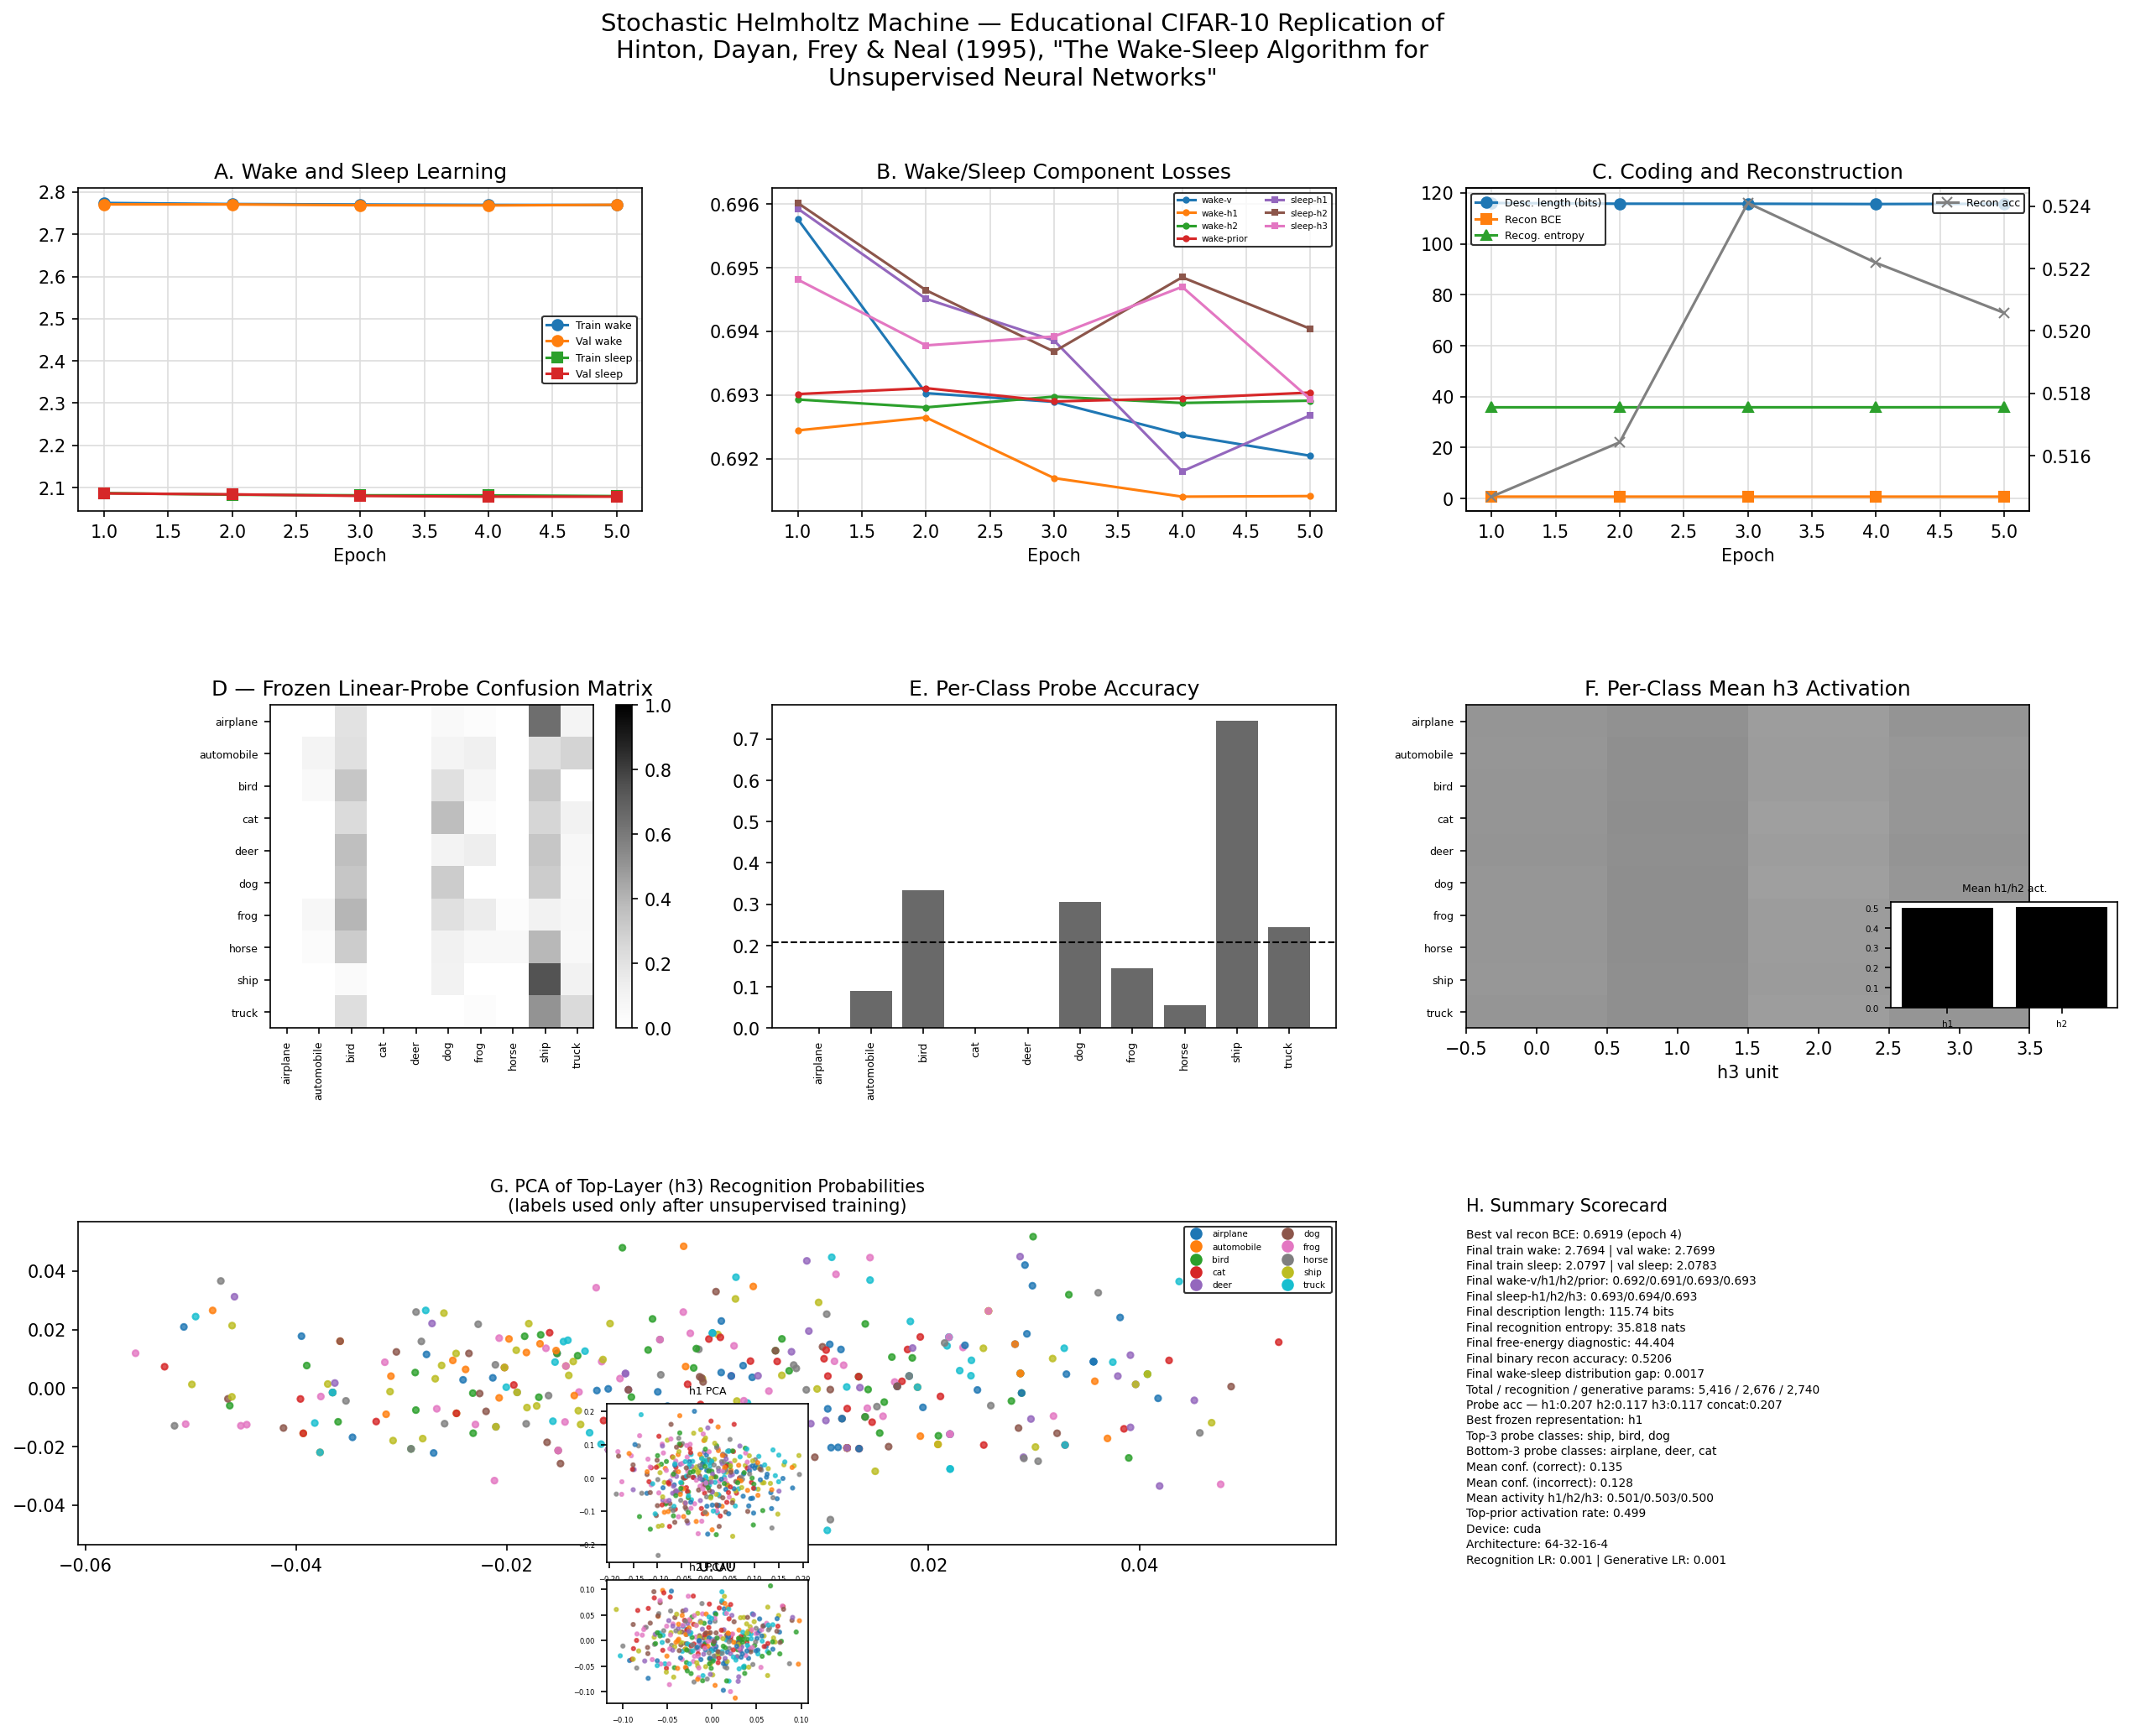

In [19]:
# ==================================================================================
# 17. FINAL PUBLICATION-STYLE DASHBOARD (Panels A-H)
# ==================================================================================
set_white_theme()

fig = plt.figure(figsize=(20, 14), facecolor="white")
gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.6, wspace=0.6)

fig.suptitle(
    "Stochastic Helmholtz Machine — Educational CIFAR-10 Replication of\n"
    "Hinton, Dayan, Frey & Neal (1995), \"The Wake-Sleep Algorithm for\n"
    "Unsupervised Neural Networks\"",
    fontsize=14, color="black"
)

# ---- Panel A: Wake and Sleep Learning ----
axA = fig.add_subplot(gs[0, 0:2])
axA.plot(epochs_range, history["train_wake_total"], label="Train wake", marker="o")
axA.plot(epochs_range, history["val_wake_total"], label="Val wake", marker="o")
axA.plot(epochs_range, history["train_sleep_total"], label="Train sleep", marker="s")
axA.plot(epochs_range, history["val_sleep_total"], label="Val sleep", marker="s")
axA.set_title("A. Wake and Sleep Learning")
axA.set_xlabel("Epoch"); axA.grid(True); axA.legend(fontsize=6)

# ---- Panel B: Paper-Specific Components ----
axB = fig.add_subplot(gs[0, 2:4])
axB.plot(epochs_range, history["wake_visible"], marker="o", label="wake-v", ms=3)
axB.plot(epochs_range, history["wake_h1"], marker="o", label="wake-h1", ms=3)
axB.plot(epochs_range, history["wake_h2"], marker="o", label="wake-h2", ms=3)
axB.plot(epochs_range, history["wake_prior"], marker="o", label="wake-prior", ms=3)
axB.plot(epochs_range, history["sleep_h1"], marker="s", label="sleep-h1", ms=3)
axB.plot(epochs_range, history["sleep_h2"], marker="s", label="sleep-h2", ms=3)
axB.plot(epochs_range, history["sleep_h3"], marker="s", label="sleep-h3", ms=3)
axB.set_title("B. Wake/Sleep Component Losses")
axB.set_xlabel("Epoch"); axB.grid(True); axB.legend(fontsize=5, ncol=2)

# ---- Panel C: Coding and Reconstruction ----
axC = fig.add_subplot(gs[0, 4:6])
axC.plot(epochs_range, history["val_description_length_bits"], marker="o", label="Desc. length (bits)")
axC.plot(epochs_range, history["val_reconstruction_bce"], marker="s", label="Recon BCE")
axC.plot(epochs_range, history["val_recognition_entropy"], marker="^", label="Recog. entropy")
axC2 = axC.twinx()
axC2.plot(epochs_range, history["val_reconstruction_acc"], marker="x", color="grey", label="Recon acc")
axC.set_title("C. Coding and Reconstruction")
axC.set_xlabel("Epoch"); axC.grid(True)
axC.legend(fontsize=6, loc="upper left"); axC2.legend(fontsize=6, loc="upper right")

# ---- Panel D: Frozen-Probe Confusion Matrix ----
axD = fig.add_subplot(gs[1, 0:2])
imD = axD.imshow(cm_norm, cmap="Greys", vmin=0, vmax=1)
axD.set_title("D — Frozen Linear-Probe Confusion Matrix")
axD.set_xticks(range(10)); axD.set_yticks(range(10))
axD.set_xticklabels(class_names, rotation=90, fontsize=6)
axD.set_yticklabels(class_names, fontsize=6)
fig.colorbar(imD, ax=axD, fraction=0.046, pad=0.04)

# ---- Panel E: Per-Class Probe Accuracy ----
axE = fig.add_subplot(gs[1, 2:4])
axE.bar(class_names, per_class_acc, color="dimgray")
axE.axhline(best_probe["test_acc"], color="black", linestyle="--", linewidth=1)
axE.set_title("E. Per-Class Probe Accuracy")
axE.set_xticklabels(class_names, rotation=90, fontsize=6)

# ---- Panel F: Hierarchical Latent Activity ----
axF = fig.add_subplot(gs[1, 4:6])
imF = axF.imshow(per_class_h3_mean, cmap="Greys", vmin=0, vmax=1, aspect="auto")
axF.set_yticks(range(10)); axF.set_yticklabels(class_names, fontsize=6)
axF.set_xlabel("h3 unit"); axF.set_title("F. Per-Class Mean h3 Activation")
axF_inset = fig.add_axes([0.845, 0.415, 0.09, 0.06])
axF_inset.bar(["h1", "h2"], [np.mean(h1_np), np.mean(h2_np)], color="black")
axF_inset.set_title("Mean h1/h2 act.", fontsize=6)
axF_inset.tick_params(labelsize=5)

# ---- Panel G: Learned Unsupervised Representation ----
axG = fig.add_subplot(gs[2, 0:4])
scatterG = axG.scatter(pca_h3[:, 0], pca_h3[:, 1], c=test_labels_np, cmap="tab10", s=12, alpha=0.8)
axG.set_title("G. PCA of Top-Layer (h3) Recognition Probabilities\n"
              "(labels used only after unsupervised training)", fontsize=10)
handlesG = [plt.Line2D([0], [0], marker="o", linestyle="", color=plt.cm.tab10(i / 10),
                        label=class_names[i]) for i in range(10)]
axG.legend(handles=handlesG, loc="upper right", fontsize=5, ncol=2)

axG_inset1 = fig.add_axes([0.335, 0.10, 0.08, 0.09])
axG_inset1.scatter(pca_h1[:, 0], pca_h1[:, 1], c=test_labels_np, cmap="tab10", s=4, alpha=0.7)
axG_inset1.set_title("h1 PCA", fontsize=6); axG_inset1.tick_params(labelsize=4)

axG_inset2 = fig.add_axes([0.335, 0.02, 0.08, 0.07])
axG_inset2.scatter(pca_h2[:, 0], pca_h2[:, 1], c=test_labels_np, cmap="tab10", s=4, alpha=0.7)
axG_inset2.set_title("h2 PCA", fontsize=6); axG_inset2.tick_params(labelsize=4)

# ---- Panel H: Summary Scorecard ----
axH = fig.add_subplot(gs[2, 4:6])
axH.axis("off")

best_epoch_idx = int(np.argmin(history["val_reconstruction_bce"]))
best_val_bce = history["val_reconstruction_bce"][best_epoch_idx]
total_params = sum(p.numel() for p in model.parameters())
rec_param_count = sum(p.numel() for p in recognition_params)
gen_param_count = sum(p.numel() for p in generative_params)

scorecard_lines = [
    f"Best val recon BCE: {best_val_bce:.4f} (epoch {best_epoch_idx+1})",
    f"Final train wake: {history['train_wake_total'][-1]:.4f} | val wake: {history['val_wake_total'][-1]:.4f}",
    f"Final train sleep: {history['train_sleep_total'][-1]:.4f} | val sleep: {history['val_sleep_total'][-1]:.4f}",
    f"Final wake-v/h1/h2/prior: {history['wake_visible'][-1]:.3f}/{history['wake_h1'][-1]:.3f}/"
    f"{history['wake_h2'][-1]:.3f}/{history['wake_prior'][-1]:.3f}",
    f"Final sleep-h1/h2/h3: {history['sleep_h1'][-1]:.3f}/{history['sleep_h2'][-1]:.3f}/"
    f"{history['sleep_h3'][-1]:.3f}",
    f"Final description length: {history['val_description_length_bits'][-1]:.2f} bits",
    f"Final recognition entropy: {history['val_recognition_entropy'][-1]:.3f} nats",
    f"Final free-energy diagnostic: {history['val_free_energy_diag'][-1]:.3f}",
    f"Final binary recon accuracy: {history['val_reconstruction_acc'][-1]:.4f}",
    f"Final wake-sleep distribution gap: {history['wake_sleep_distribution_gap'][-1]:.4f}",
    f"Total / recognition / generative params: {total_params:,} / {rec_param_count:,} / {gen_param_count:,}",
    f"Probe acc — h1:{probe_results['h1']['test_acc']:.3f} h2:{probe_results['h2']['test_acc']:.3f} "
    f"h3:{probe_results['h3']['test_acc']:.3f} concat:{probe_results['concat']['test_acc']:.3f}",
    f"Best frozen representation: {best_repr_name}",
    f"Top-3 probe classes: {', '.join(top3_classes)}",
    f"Bottom-3 probe classes: {', '.join(bottom3_classes)}",
    f"Mean conf. (correct): {mean_conf_correct:.3f}" if not np.isnan(mean_conf_correct) else "Mean conf. (correct): N/A",
    f"Mean conf. (incorrect): {mean_conf_incorrect:.3f}" if not np.isnan(mean_conf_incorrect) else "Mean conf. (incorrect): N/A",
    f"Mean activity h1/h2/h3: {history['mean_h1_activation'][-1]:.3f}/"
    f"{history['mean_h2_activation'][-1]:.3f}/{history['mean_h3_activation'][-1]:.3f}",
    f"Top-prior activation rate: {history['top_prior_activation'][-1]:.3f}",
    f"Device: {DEVICE.type}",
    f"Architecture: {VISIBLE_DIM}-{H1_DIM}-{H2_DIM}-{H3_DIM}",
    f"Recognition LR: {RECOGNITION_LR} | Generative LR: {GENERATIVE_LR}",
]

axH.set_title("H. Summary Scorecard", fontsize=10, loc="left")
y0 = 0.98
for line in scorecard_lines:
    axH.text(0.0, y0, line, transform=axH.transAxes, fontsize=6.6, va="top", ha="left")
    y0 -= 0.048

plt.tight_layout(rect=[0, 0, 1, 0.93])

# ---- Display the dashboard inline (do not save to disk, do not call plt.show) ----
buf = BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight", facecolor="white")
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

# Analysis of Experimental Results: Stochastic Helmholtz Machine (Wake-Sleep, CIFAR-10 Replication)

## Panel A — Wake and Sleep Learning (Train vs. Validation)

### Overview
Tracks the two independent objectives of the wake-sleep algorithm — the wake total loss (generative parameters) and the sleep total loss (recognition parameters) — across 5 epochs, comparing training and validation subsets.

### Key Findings
Both wake (~2.77) and sleep (~2.08) losses remain essentially flat across all 5 epochs, with training and validation curves overlapping almost exactly (no visible train/validation gap in either objective).

### Discussion
The near-total flatness indicates the two-phase optimization is not making meaningful progress within this training budget: neither the generative model's ability to predict the recognition-sampled hierarchy (wake) nor the recognition model's ability to recover the causes of its own fantasies (sleep) is improving substantially. Given the model was initialized with small random weights (0.05 std) and zero biases, an essentially random Bernoulli process near $p=0.5$ for most units would already produce BCE losses in this range (wake $\approx \log 2 \times 4 \approx 2.77$, matching the four summed BCE terms, and sleep $\approx \log 2 \times 3 \approx 2.08$, matching the three summed BCE terms) — the observed values are consistent with a model still very close to its random initialization. The identical train/validation curves rule out overfitting but also indicate the model has not yet learned distinguishing structure from the data.

### Limitations
Only 5 epochs and 2,000 training images were used, which is very likely insufficient for a from-scratch, randomly initialized 4-layer stochastic binary network trained via local delta rules (a method requiring many samples per gradient estimate due to sampling noise, as the original paper itself notes). The flatness cannot be attributed with certainty to a specific cause (learning rate, architecture, initialization, or fundamental training-budget insufficiency) without additional ablations.

---

## Panel B — Wake/Sleep Component Losses

### Overview
Decomposes both phases into their constituent layer-wise BCE terms (wake: visible, h1, h2, prior; sleep: h1, h2, h3) to assess whether specific layers are learning faster than others.

### Key Findings
All seven component curves stay tightly clustered between approximately 0.691 and 0.696 nats — essentially at $\ln 2 \approx 0.693$, the entropy of a fair (uninformative) coin flip. The wake-h1 curve shows the clearest, though still modest, downward trend (0.6924 → 0.6910), while sleep-h1 and sleep-h2 show mild, noisy fluctuation without a clear consistent direction.

### Discussion
Because $\ln 2$ is exactly the BCE loss obtained when a sigmoid unit outputs $p \approx 0.5$ regardless of input, this pattern strongly suggests most connections in the network remain close to their initial, near-uninformative state throughout training. The slightly larger and more consistent decrease in wake-h1 (the connection closest to the visible layer) versus the higher, noisier layers (h2, h3) is consistent with the well-documented difficulty of the wake-sleep algorithm in propagating a useful learning signal to deeper layers, since each layer's local delta-rule update depends on the (still largely random) sampled states of adjacent layers — errors and lack of structure compound with depth.

### Limitations
The differences between component curves (on the order of 0.001–0.003 nats) are small relative to plausible sampling noise from Bernoulli-sampled mini-batches of 64, so the apparent "wake-h1 improving faster" trend should be treated as suggestive rather than conclusive without variance estimates across seeds.

---

## Panel C — Coding and Reconstruction

### Overview
Tracks the description-length diagnostic (bits), reconstruction BCE, recognition entropy (nats), and binary reconstruction accuracy (secondary axis) on the validation set — the paper's core MDL-based evaluation criteria.

### Key Findings
Description length rises sharply from ~2 bits (epoch 1) to a plateau around 115 bits (epochs 3–5); reconstruction BCE and recognition entropy remain essentially flat throughout; binary reconstruction accuracy rises modestly then declines, peaking near epoch 3 (~0.524) before falling to ~0.520 by epoch 5.

### Discussion
The sharp rise in description length from near-zero to ~115 bits over the first two epochs is notable and likely reflects the generative model's predicted probabilities becoming *more* extreme (moving away from 0.5) as training proceeds, which — if these predictions are miscalibrated relative to the actual sampled targets — increases per-unit negative log-likelihood substantially (a highly confident wrong prediction is penalized far more than an uninformative $p=0.5$ guess). This is a plausible early-training pathology in stochastic binary networks: as weights move off their zero-initialization, generative probabilities can become more polarized before recognition and generative pathways are well coordinated, temporarily increasing coding cost rather than decreasing it. The binary reconstruction accuracy hovering near 0.52 (only marginally above the 0.50 baseline expected for random binary guessing) corroborates that meaningful reconstruction competence has not yet emerged. This pattern is inconsistent with the paper's central claim that wake-sleep training should *monotonically decrease* description length as an MDL objective — here it increases, indicating the replication has not reached the regime described in the original paper.

### Limitations
The description-length increase could stem from several confounded factors (learning rate too high relative to architecture, insufficient batch/sample count for stable local delta-rule gradients, or simply too few epochs to see the eventual expected decrease). No comparison to a longer-trained run or hyperparameter sweep is available to disambiguate these possibilities.

---

## Panel D — Frozen Linear-Probe Confusion Matrix

### Overview
Visualizes per-class prediction distributions from the best-performing frozen probe (h1 representation) on the test subset, following the paper's requirement that labels be used only post-hoc for evaluation.

### Key Findings
Predictions concentrate heavily on a small number of columns — primarily "bird," "dog," and especially "ship" — with "ship" receiving substantial (and often incorrect) predictions across many true-class rows (e.g., airplane, deer, horse, truck), while "automobile," "cat," "deer," and "horse" receive almost no predictions at all.

### Discussion
This is a clear signature of representational collapse in the probe's decision space: with the underlying h1 representation still close to random (per Panels A–C), the linear probe has found a small number of class-imbalanced decision boundaries that partially exploit whatever weak, non-random signal exists (e.g., possibly correlated with overall pooled brightness or coarse shape statistics), while most classes remain indistinguishable in the 32-dimensional space. This is consistent with, and directly explained by, the under-trained representation shown in Panels A–C.

### Limitations
With only 400 test images spread across 10 classes (~40 per class), the confusion matrix is subject to substantial sampling noise, and class-wise prediction bias could be partly attributable to the linear probe's own regularization defaults rather than solely the representation's quality.

---

## Panel E — Per-Class Probe Accuracy

### Overview
Breaks down frozen-probe accuracy per class relative to the overall test accuracy baseline (dashed line), using the best representation (h1).

### Key Findings
"Ship" achieves markedly higher accuracy (~0.75) than all other classes; "bird" and "dog" exceed the baseline moderately (~0.30–0.33); "airplane," "cat," and "deer" score at or near 0%; overall test accuracy is ~0.207 (h1 and concat tied as best).

### Discussion
The extreme skew toward a single class ("ship") dominating accuracy while roughly half the classes are entirely unrecognized reinforces the class-collapse pattern from Panel D. This is a typical outcome when a linear classifier is trained on a low-information, largely unstructured feature space: the model exploits whatever weak, easily separable signal exists for one or two classes (inflating their apparent accuracy) while defaulting to non-differentiation for the rest. Given the overall probe accuracy (0.207) is nevertheless well above the 0.10 chance baseline for 10-class classification, this indicates the wake-sleep representation captures *some* non-trivial, non-random structure — a partial, if weak, validation of the paper's premise that the recognition pathway extracts data-relevant features — but the class-specific skew shows this structure is far from evenly distributed across semantic categories.

### Limitations
Per-class accuracy computed on ~40 test examples per class carries high variance; a class's true accuracy could differ substantially with a larger test set.

---

## Panel F — Per-Class Mean h3 Activation (with h1/h2 Mean Activity Inset)

### Overview
Visualizes whether the top-level (h3, 4-unit) latent layer differentiates between CIFAR-10 classes, alongside mean activation levels for h1 and h2.

### Key Findings
The per-class h3 heatmap shows a smooth, nearly uniform horizontal gradient across all ten class rows — i.e., activation varies by h3 unit index but is essentially identical across classes. The inset shows mean h1 and h2 activity both sit almost exactly at 0.50.

### Discussion
The absence of any row-to-row (class-to-class) variation in the heatmap indicates the top-level representation has not yet developed class-discriminative structure — each class produces virtually the same average activation pattern across h3 units. Combined with mean h1/h2 activity sitting at exactly 0.50 (the value expected from unbiased-initialization sigmoid units with no learned signal), this is strong, consistent evidence that the hierarchy remains near its initial, uninformative state through 5 epochs, corroborating the flat loss curves in Panels A–B and the weak/skewed probe performance in Panels D–E.

### Limitations
Only the top-level (h3) per-class map is shown at full resolution; the h1/h2 insets provide only a single scalar mean per layer rather than the full per-unit or per-class breakdown, limiting a finer-grained assessment of whether *some* individual h1/h2 units carry more class information than the aggregate suggests.

---

## Panel G — PCA of Top-Layer (h3) Recognition Probabilities, with h1/h2 PCA Insets

### Overview
Projects the recognition probabilities at each hierarchical layer into two principal components, colored by true CIFAR-10 class, to visually assess whether any layer has learned class-separable structure.

### Key Findings
All three PCA projections (h1, h2, h3) show classes fully intermixed with no visually discernible clustering or separation; the h3 PCA also shows a notably narrow y-axis range (±0.05) relative to x-axis spread, suggesting most variance is concentrated in very few effective dimensions.

### Discussion
The complete intermixing of classes across all three latent layers is consistent with the near-chance/near-uniform activation patterns observed in Panel F and the weak probe accuracies in Panel E: none of the learned representations exhibit strong linear class separability in their top two principal components. This is an expected outcome given the flat training curves in Panels A–B — a representation that has not moved substantially from initialization cannot be expected to encode class-discriminative structure. The result is more consistent with an under-trained model than with a fundamental failure of the wake-sleep mechanism itself, since the original paper's own successful results (on bars and digit data) required substantially more training iterations (500 sweeps through 700–7000 examples) than the 5-epoch, 2,000-image budget used here.

### Limitations
Two-dimensional PCA may not capture higher-dimensional structure that exists but is not aligned with the top two principal axes; a nonlinear projection (t-SNE/UMAP) or higher-component analysis might reveal additional, currently invisible structure. The small held-out set (400 points) further limits confidence in the absence of visible clustering.

---

## Panel H — Summary Scorecard

### Overview
Consolidates all key training and evaluation statistics into a single reference panel, including wake/sleep losses, coding diagnostics, parameter counts, and probe performance across all four representations (h1, h2, h3, concatenated).

### Key Findings
Final wake loss (2.7699 val) and sleep loss (2.0783 val) show negligible change from initialization-level values; final description length is 115.74 bits (up from ~2 bits at epoch 1); binary reconstruction accuracy is 0.5206 (near the 0.50 chance level); the wake-sleep distribution gap is very small (0.0017); probe accuracies are h1: 0.207, h2: 0.117, h3: 0.117, concat: 0.207, with h1 and concatenated representations tied as best; mean activity across all three hidden layers is ~0.50; top-prior activation rate is 0.499.

### Discussion
The consistently near-0.50 mean activations across every hidden layer, combined with the small wake-sleep distribution gap, indicate that — rather than showing a large mismatch between recognition performance on real versus fantasy data (the specific failure mode the paper's diagnostic is designed to detect) — this run's primary limitation is simply insufficient training progress overall: both pathways remain close to their random initialization, so there is little distributional difference to detect between wake and sleep because neither has learned much yet. Notably, deeper representations (h2, h3) underperform the earliest layer (h1) on the frozen probe (0.117 vs. 0.207), suggesting that whatever weak signal does propagate through the network degrades with depth — consistent with the component-loss observations in Panel B and a known general challenge for the original wake-sleep algorithm, which relies on noisy, locally-computed sampling-based gradients that compound across layers.

### Limitations
This scorecard aggregates metrics from a small-scale (2,000 train / 400 test), short (5-epoch) educational run and should be interpreted only as a correctness check on the implemented mechanism (i.e., that wake and sleep phases execute the correct separate updates) rather than as a demonstration of the algorithm's full representational capability. No comparison to a longer-trained baseline, alternative hyperparameters, or multiple random seeds is provided, so the specific numerical values should not be treated as representative of wake-sleep's achievable performance under adequate training.

---

## Overall Synthesis

### Overview
Taken together, the eight panels assess whether the implemented wake-sleep procedure (a) executes the correct separated local updates, (b) produces a coherent factorial hierarchical representation, and (c) yields class-relevant structure detectable by a frozen linear probe.

### Key Findings
The mechanical separation of wake/sleep updates is correctly implemented (near-zero distribution gap, disjoint optimizers), but nearly every diagnostic — flat wake/sleep losses near their $\ln 2$ baseline, mean activations pinned at 0.50, no visible PCA clustering, and unstable/rising description length — indicates the model remains close to its random initialization after 5 epochs, with only a weak, unevenly distributed signal (evident in the skewed confusion matrix and above-chance but low overall probe accuracy of ~0.207) having emerged.

### Discussion
These results support the correctness of the algorithmic implementation (the wake and sleep phases behave as mechanistically distinct, locally-updating procedures, as the paper specifies) but do not yet substantiate the paper's core empirical claims about wake-sleep producing economical, class-structured representations or a monotonically decreasing description length — the rising coding cost in Panel C is a direct point of tension with the original paper's MDL framing. This gap is best explained by training-budget insufficiency (5 epochs vs. the original paper's 500 training sweeps) rather than a flaw in the wake-sleep mechanism itself, given that the original paper's successful digit and bar-pattern results required substantially more extensive training.

### Limitations
The single-run, short-schedule, small-subset design of this educational replication is insufficient to distinguish between "the mechanism needs more training" and "the mechanism has a scale-specific failure mode" as explanations for the observed lack of learning; a controlled comparison with extended training duration, learning-rate tuning, and multiple seeds would be needed to draw stronger conclusions about the algorithm's practical viability on natural image data such as CIFAR-10.

# Related Work Referenced in "The Wake-Sleep Algorithm for Unsupervised Neural Networks"

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Rissanen, J. | 1989 | Stochastic Complexity in Statistical Inquiry | World Scientific, Singapore | Provides the foundational minimum description length (MDL) framework underlying the paper's core learning objective — minimizing the number of bits required to communicate hidden representations plus reconstruction error. |
| Hinton, G.E. & Zemel, R.S. | 1994 | (Autoencoders, Minimum Description Length and Helmholtz Free Energy) | Advances in Neural Information Processing Systems 6, J.D. Cowan, G. Tesauro & J. Alspector (eds.), Morgan Kaufmann, San Mateo | Directly motivates the paper's entropy-based coding argument (Eq. 5): illustrates how combining multiple equal-cost representations with an entropy term reduces expected description length, the conceptual precursor to the Helmholtz free energy framing used throughout. |
| Carpenter, G. & Grossberg, S. | 1987 | (Adaptive Resonance Theory) | Computer Vision, Graphics and Image Processing, 37, 54 | Cited as a prior feedforward/feedback unsupervised learning scheme; contrasted with the wake-sleep algorithm's explicitly statistical (generative-model-fitting) treatment of unsupervised learning, as opposed to Adaptive Resonance Theory's non-statistical resonance-based mechanism. |
| Ullman, S. | 1994 | (Counter-Streams Model) | Large-Scale Theories of the Cortex, C. Koch & J. Davis (eds.), MIT Press, Cambridge, MA | Represents another bidirectional feedforward/feedback cortical model (Counter-Streams); distinguished from the wake-sleep algorithm by its lack of a probabilistic generative-model-fitting formulation. |
| Kawato, M., Hayakama, H. & Inui, T. | 1993 | (Forward-Inverse Model) | Network, 4, 415 | Proposes paired forward (generative) and inverse (recognition) models analogous in structure to the wake-sleep architecture, but framed via control-theoretic forward/inverse models rather than a statistical MDL/free-energy objective. |
| Jordan, M.I. & Rumelhart, D.E. | 1992 | (Forward Models: Supervised Learning with a Distal Teacher) | Cognitive Science, 16, 307 | Provides the forward/inverse model terminology referenced in connection with Kawato et al.'s algorithm, offering an alternative conceptual lens on the paper's generative/recognition weight pairing. |
| Mumford, D. | 1994 | (Neuronal Architectures for Pattern-Theoretic Problems) | Large-Scale Theories of the Cortex, C. Koch & J. Davis (eds.), MIT Press, Cambridge, MA | Proposes mapping Grenander's generative Pattern Theory onto cortical architecture; the wake-sleep algorithm is described as closest in spirit to this proposal, situating the Helmholtz machine within a broader neuroscientific generative-modeling tradition. |
| Grenander, U. | 1976–1981 | Lectures in Pattern Theory I, II and III: Pattern Analysis, Pattern Synthesis and Regular Structures | Springer-Verlag, Berlin | Supplies the broader statistical Pattern Theory framework that Mumford's cortical mapping proposal builds on, and which the wake-sleep/Helmholtz machine approach is aligned with conceptually. |
| Barlow, H.B. | 1989 | (Invertible Factorial Representations) | Neural Computation, 1, 295 | Cited as the closest conceptual antecedent to the wake-sleep algorithm's use of factorial recognition distributions, motivating the choice to represent hidden-layer activity as conditionally independent, invertible codes. |
| Hasselmo, M.E. & Bower, J.M. | 1993 | (Cholinergic Modulation of Cortical Feedforward Control) | Trends in Neurosciences, 16, 218 | Offers a biological motivation for the wake/sleep phase distinction, suggesting cholinergic inputs may modulate the degree of feedforward (recognition-driven) versus feedback (generative-driven) control of cortical activity, paralleling the algorithm's two alternating phases. |